# EDA: Volúmenes DICOM

Este notebook contiene el EDA de los volúmenes originales en formato DICOM.

In [ ]:
# importaciones de librerias
import os
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pydicom import dcmread

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)

In [14]:
# Ruta DICOMs originales
DICOM_DIR = Path("/home/mcribilles/tfm/casosradiomica")
print("Ruta:", DICOM_DIR)

Ruta: /home/mcribilles/tfm/casosradiomica


In [15]:
# carpetas iniciales de pacientes
if not DICOM_DIR.exists():
    raise FileNotFoundError(f"No existe la ruta DICOM: {DICOM_DIR}")

pacientes = sorted([p for p in DICOM_DIR.iterdir() if p.is_dir()])
print(f"Pacientes detectados con carpeta DICOM: {len(pacientes)}")
if pacientes:
    print("Primeros pacientes:", [p.name for p in pacientes[:10]])

Pacientes detectados con carpeta DICOM: 210
Primeros pacientes: ['100HNnSNH', '101HNnSN', '102HANX', '103MANX', '104HASN', '105HENX', '106HASH', '107HNnNX', '108HENX', '109HANX']


## Funciones auxiliares

Usamos lectura ligera del DICOM para evitar cargar píxeles completos cuando no hace falta.

In [16]:
# funcion para listar los archivos DICOM de un paciente
def list_candidate_files(patient_dir: Path):
    files = []
    for root, _, filenames in os.walk(patient_dir):
        for name in filenames:
            files.append(Path(root) / name)
    return sorted(files)

In [17]:
#funcion para leer los metadatos de un archivo DICOM
def read_dicom_metadata(example_path: Path): 
    ds = dcmread(str(example_path), stop_before_pixels=True, force=True)
    spacing = getattr(ds, "PixelSpacing", [np.nan, np.nan])
    thickness = getattr(ds, "SliceThickness", np.nan)
    return {
        "Height": getattr(ds, "Rows", np.nan),
        "Width": getattr(ds, "Columns", np.nan),
        "Spacing_X": spacing[0] if len(spacing) > 0 else np.nan,
        "Spacing_Y": spacing[1] if len(spacing) > 1 else np.nan,
        "Spacing_Z": thickness,
        "Modality": getattr(ds, "Modality", None),
        "Manufacturer": getattr(ds, "Manufacturer", None),
    }

## Recorrido por pacientes y resumen por volumen

Para cada paciente contamos slices y leemos un ejemplo para extraer metadatos espaciales.


In [18]:
resumen_dicom = [] #vamos a ir guardando un resumen de los volumenes
errores_dicom = []

for paciente_path in pacientes: 
    paciente_id = paciente_path.name
    slices_paths = list_candidate_files(paciente_path)
    num_slices = len(slices_paths)

    if num_slices == 0:
        errores_dicom.append({
            "Paciente": paciente_id,
            "Error": "Sin archivos dentro de la carpeta"
        })
        continue

    ejemplo_path = slices_paths[0]
    try:
        meta = read_dicom_metadata(ejemplo_path)
        resumen_dicom.append({
            "Paciente": paciente_id,
            "Num_slices": num_slices,
            **meta,
            "Example_file": str(ejemplo_path),
        })
    except Exception as e:
        errores_dicom.append({
            "Paciente": paciente_id,
            "Example_file": str(ejemplo_path),
            "Error": str(e),
        })

df_resumen = pd.DataFrame(resumen_dicom)
df_errores = pd.DataFrame(errores_dicom)

print("Volumenes validos:", len(df_resumen))
print("Pacientes con error:", len(df_errores))
display(df_resumen.head())
if not df_errores.empty:
    display(df_errores.head())

Volumenes validos: 209
Pacientes con error: 1


,Paciente,Num_slices,Height,Width,Spacing_X,Spacing_Y,Spacing_Z,Modality,Manufacturer,Example_file
0,100HNnSNH,947,NaN,NaN,NaN,NaN,NaN,NaN,NaN,/home/mcribilles/tfm/casosradiomica/100HNnSNH/...
1,101HNnSN,222,768.0,768.0,0.410156,0.410156,3.0,CT,Philips,/home/mcribilles/tfm/casosradiomica/101HNnSN/0...
2,102HANX,120,NaN,NaN,NaN,NaN,NaN,NaN,NaN,/home/mcribilles/tfm/casosradiomica/102HANX/DI...
3,103MANX,258,NaN,NaN,NaN,NaN,NaN,NaN,NaN,/home/mcribilles/tfm/casosradiomica/103MANX/DI...
4,104HASN,216,NaN,NaN,NaN,NaN,NaN,NaN,NaN,/home/mcribilles/tfm/casosradiomica/104HASN/DI...


,Paciente,Error
0,166MANX,Sin archivos dentro de la carpeta


## Resumen descriptivo


In [19]:
if df_resumen.empty:
    print("No se genero resumen: no se encontraron volumenes validos.")
else:
    display(df_resumen.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Paciente,209,209,100HNnSNH,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Num_slices,209.0,NaN,NaN,NaN,372.205742,213.653072,6.0,232.0,298.0,502.0,1107.0
Height,70.0,NaN,NaN,NaN,621.942857,149.298251,512.0,512.0,512.0,768.0,1296.0
Width,70.0,NaN,NaN,NaN,621.942857,149.298251,512.0,512.0,512.0,768.0,1296.0
Spacing_X,70.0,NaN,NaN,NaN,0.639365,0.167834,0.347656,0.480143,0.65918,0.78125,0.947266
Spacing_Y,70.0,NaN,NaN,NaN,0.639365,0.167834,0.347656,0.480143,0.65918,0.78125,0.947266
Spacing_Z,70.0,NaN,NaN,NaN,1.710714,1.338285,1.0,1.0,1.25,2.0,10.0
Modality,70,1,CT,70,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Manufacturer,70,4,Philips,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Example_file,209,209,/home/mcribilles/tfm/casosradiomica/100HNnSNH/...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Distribución de tamaños de volumen


In [20]:
if not df_resumen.empty:
    shapes_list = list(zip(df_resumen["Num_slices"], df_resumen["Height"], df_resumen["Width"]))
    shapes_counter = Counter(shapes_list)
    print("Distribución de tamaños (Num_slices, Height, Width):")
    for shape, count in shapes_counter.most_common():
        print(f"{shape}: {count} volúmenes")

Distribución de tamaños (Num_slices, Height, Width):
(748, 512.0, 512.0): 2 volúmenes
(260, 512.0, 512.0): 2 volúmenes
(341, 768.0, 768.0): 2 volúmenes
(947, nan, nan): 1 volúmenes
(222, 768.0, 768.0): 1 volúmenes
(120, nan, nan): 1 volúmenes
(258, nan, nan): 1 volúmenes
(216, nan, nan): 1 volúmenes
(225, nan, nan): 1 volúmenes
(204, nan, nan): 1 volúmenes
(308, nan, nan): 1 volúmenes
(305, nan, nan): 1 volúmenes
(232, nan, nan): 1 volúmenes
(297, 768.0, 768.0): 1 volúmenes
(301, nan, nan): 1 volúmenes
(162, 512.0, 512.0): 1 volúmenes
(232, nan, nan): 1 volúmenes
(175, 512.0, 512.0): 1 volúmenes
(325, nan, nan): 1 volúmenes
(225, nan, nan): 1 volúmenes
(299, nan, nan): 1 volúmenes
(169, nan, nan): 1 volúmenes
(838, nan, nan): 1 volúmenes
(228, 512.0, 512.0): 1 volúmenes
(198, nan, nan): 1 volúmenes
(293, nan, nan): 1 volúmenes
(293, nan, nan): 1 volúmenes
(977, nan, nan): 1 volúmenes
(268, nan, nan): 1 volúmenes
(232, nan, nan): 1 volúmenes
(287, nan, nan): 1 volúmenes
(276, nan, nan):

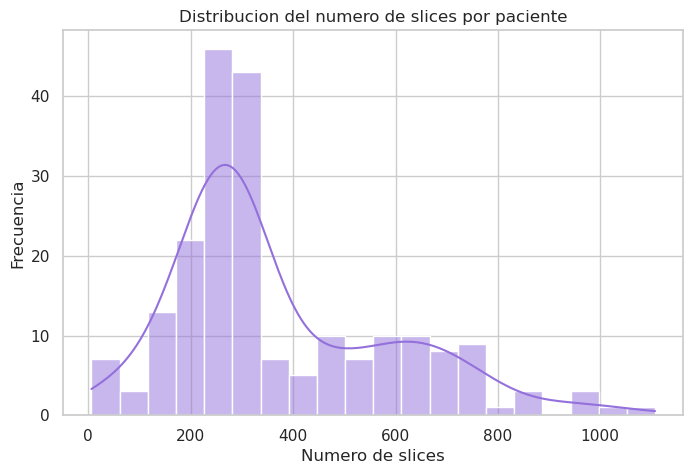

In [21]:
if not df_resumen.empty:
    plt.figure(figsize=(8, 5))
    sns.histplot(df_resumen["Num_slices"], bins=20, kde=True, color="mediumpurple")
    plt.title("Distribucion del numero de slices por paciente")
    plt.xlabel("Numero de slices")
    plt.ylabel("Frecuencia")
    plt.show()

## Distribución de resoluciones `(Height, Width)`


In [22]:
if not df_resumen.empty:
    resoluciones_counter = (
        df_resumen.groupby(["Height", "Width"])
        .size()
        .reset_index(name="Count")
        .sort_values("Count", ascending=False)
    )
    display(resoluciones_counter)

,Height,Width,Count
0,512.0,512.0,42
1,768.0,768.0,27
2,1296.0,1296.0,1


## Spacing espacial


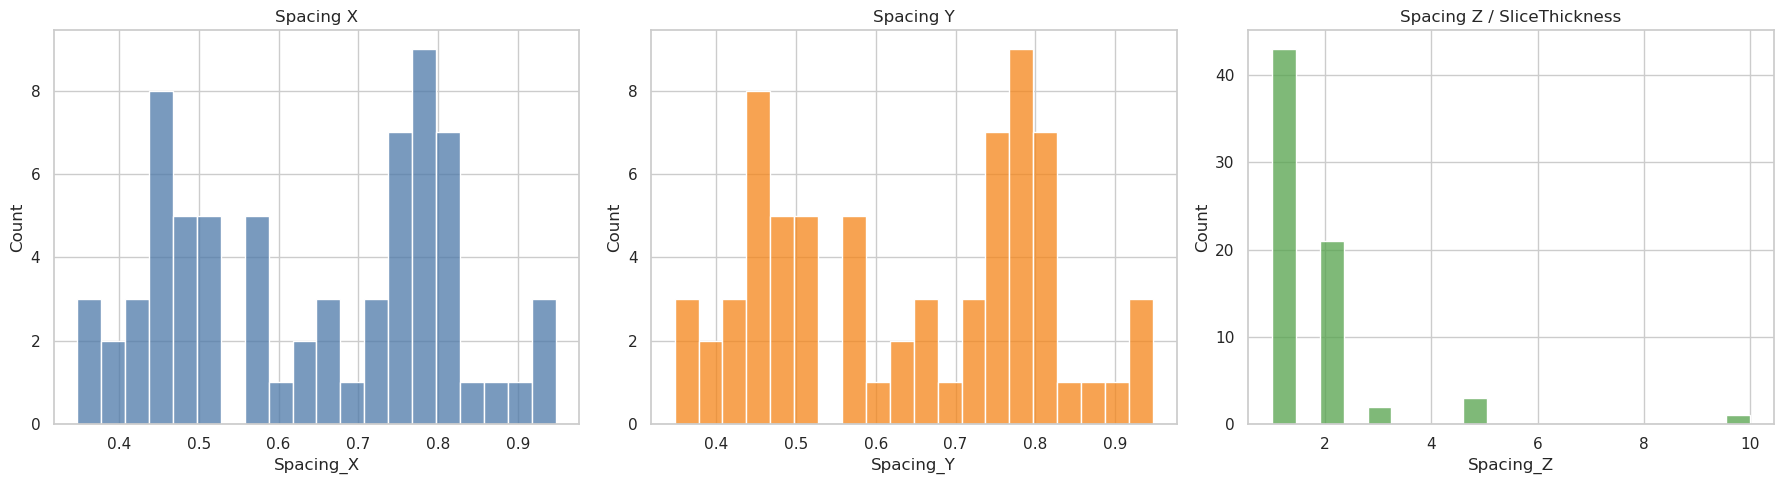

In [23]:
if not df_resumen.empty:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    sns.histplot(df_resumen["Spacing_X"].astype(float), bins=20, ax=axes[0], color="#4c78a8")
    axes[0].set_title("Spacing X")

    sns.histplot(df_resumen["Spacing_Y"].astype(float), bins=20, ax=axes[1], color="#f58518")
    axes[1].set_title("Spacing Y")

    spacing_z = pd.to_numeric(df_resumen["Spacing_Z"], errors="coerce")
    sns.histplot(spacing_z.dropna(), bins=20, ax=axes[2], color="#54a24b")
    axes[2].set_title("Spacing Z / SliceThickness")

    plt.tight_layout()
    plt.show()

## Casos extremos y heterogeneidad


In [ ]:
if not df_resumen.empty:
    print("Volumenes con menos slices:")
    display(df_resumen.sort_values("Num_slices").head(10))

    print("Volumenes con mas slices:")
    display(df_resumen.sort_values("Num_slices", ascending=False).head(10))

Volúmenes con menos slices:


,Paciente,Num_slices,Height,Width,Spacing_X,Spacing_Y,Spacing_Z,Modality,Manufacturer,Example_file
82,176HASH,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,/home/mcribilles/tfm/casosradiomica/176HASH/DI...
117,207HLSN,7,1296.0,1296.0,0.455215,0.455200,10.0,CT,Philips,/home/mcribilles/tfm/casosradiomica/207HLSN/2A...
115,205HENX,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,/home/mcribilles/tfm/casosradiomica/205HENX/DI...
159,55HASN,44,NaN,NaN,NaN,NaN,NaN,NaN,NaN,/home/mcribilles/tfm/casosradiomica/55HASN/DIC...
154,50HANX,51,768.0,768.0,0.510417,0.510417,5.0,CT,Philips,/home/mcribilles/tfm/casosradiomica/50HANX/5EM...
138,36HENX,56,768.0,768.0,0.440104,0.440104,5.0,CT,Philips,/home/mcribilles/tfm/casosradiomica/36HENX/5KI...
125,24MANX,59,768.0,768.0,0.442708,0.442708,5.0,CT,Philips,/home/mcribilles/tfm/casosradiomica/24MANX/1AM...
176,70HENX,71,NaN,NaN,NaN,NaN,NaN,NaN,NaN,/home/mcribilles/tfm/casosradiomica/70HENX/DIC...
108,19MANX,72,NaN,NaN,NaN,NaN,NaN,NaN,NaN,/home/mcribilles/tfm/casosradiomica/19MANX/DIC...
40,137HASN,74,NaN,NaN,NaN,NaN,NaN,NaN,NaN,/home/mcribilles/tfm/casosradiomica/137HASN/DI...


Volúmenes con más slices:


,Paciente,Num_slices,Height,Width,Spacing_X,Spacing_Y,Spacing_Z,Modality,Manufacturer,Example_file
67,161HASN,1107,NaN,NaN,NaN,NaN,NaN,NaN,NaN,/home/mcribilles/tfm/casosradiomica/161HASN/DI...
96,189HANX,1003,512.0,512.0,0.945312,0.945312,1.0,CT,SIEMENS,/home/mcribilles/tfm/casosradiomica/189HANX/01...
25,123HASH,977,NaN,NaN,NaN,NaN,NaN,NaN,NaN,/home/mcribilles/tfm/casosradiomica/123HASH/DI...
0,100HNnSNH,947,NaN,NaN,NaN,NaN,NaN,NaN,NaN,/home/mcribilles/tfm/casosradiomica/100HNnSNH/...
201,93HESN,944,NaN,NaN,NaN,NaN,NaN,NaN,NaN,/home/mcribilles/tfm/casosradiomica/93HESN/DIC...
121,210MASN,859,512.0,512.0,0.795027,0.795027,1.0,CT,Siemens Healthineers,/home/mcribilles/tfm/casosradiomica/210MASN/C5...
20,119HESN,838,NaN,NaN,NaN,NaN,NaN,NaN,NaN,/home/mcribilles/tfm/casosradiomica/119HESN/DI...
44,140HASNh,838,NaN,NaN,NaN,NaN,NaN,NaN,NaN,/home/mcribilles/tfm/casosradiomica/140HASNh/D...
98,190HNeNX,802,NaN,NaN,NaN,NaN,NaN,NaN,NaN,/home/mcribilles/tfm/casosradiomica/190HNeNX/D...
203,95HASH,769,512.0,512.0,0.806437,0.806437,1.0,CT,Siemens Healthineers,/home/mcribilles/tfm/casosradiomica/95HASH/4H4...


## EDA robusto por series DICOM

El análisis anterior resume una carpeta por paciente, pero en DICOM una carpeta puede contener varias series o archivos que no son imagen axial CT. A partir de aquí se analiza cada `SeriesInstanceUID` por separado y después se selecciona la serie CT principal de cada paciente.

In [ ]:
# funciones para convertir metadatos DICOM a valores manejables en pandas
from IPython.display import display

EDA_OUTPUT_DIR = Path("/home/mcribilles/tfm/eda")
EDA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def is_missing_value(value):
    if value is None:
        return True
    if isinstance(value, float) and np.isnan(value):
        return True
    return False


def dicom_value_to_python(value):
    """Convierte valores pydicom, MultiValue y numpy a tipos simples."""
    if value is None:
        return None
    if isinstance(value, bytes):
        return value.decode(errors="ignore")
    if isinstance(value, (str, int, float, bool)):
        return value
    if isinstance(value, (np.integer, np.floating)):
        return value.item()
    try:
        return [dicom_value_to_python(v) for v in value]
    except TypeError:
        return str(value)


def numeric_or_nan(value):
    if value is None:
        return np.nan
    try:
        return float(value)
    except (TypeError, ValueError):
        return np.nan


def first_or_nan(values):
    for value in values:
        if not is_missing_value(value):
            return value
    return np.nan


def hashable_dicom_value(value):
    if isinstance(value, list):
        return tuple(hashable_dicom_value(v) for v in value)
    if isinstance(value, dict):
        return tuple(sorted((k, hashable_dicom_value(v)) for k, v in value.items()))
    return value


def display_dicom_value(value):
    if isinstance(value, list):
        return " | ".join(str(v) for v in value)
    return value


def mode_or_nan(values):
    clean = []
    for value in values:
        if not is_missing_value(value):
            clean.append(value)
    if not clean:
        return np.nan
    keys = [hashable_dicom_value(value) for value in clean]
    most_common_key = Counter(keys).most_common(1)[0][0]
    for value in clean:
        if hashable_dicom_value(value) == most_common_key:
            return display_dicom_value(value)
    return np.nan


def n_unique_non_missing(values):
    clean = []
    for value in values:
        if not is_missing_value(value):
            clean.append(str(value))
    return len(set(clean))


def as_float_array(value):
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return None
    if isinstance(value, str):
        text = value.strip().replace("[", "").replace("]", "").replace("(", "").replace(")", "")
        parts = [part for part in text.replace(";", ",").split(",") if part.strip()]
    else:
        try:
            parts = list(value)
        except TypeError:
            return None
    try:
        arr = np.asarray(parts, dtype=float)
    except (TypeError, ValueError):
        return None
    return arr if arr.size else None


def normal_from_orientation(orientation_value):
    orientation = as_float_array(orientation_value)
    if orientation is None or orientation.size < 6:
        return np.array([0.0, 0.0, 1.0])
    row_cosines = orientation[:3]
    col_cosines = orientation[3:6]
    normal = np.cross(row_cosines, col_cosines)
    norm = np.linalg.norm(normal)
    if norm == 0:
        return np.array([0.0, 0.0, 1.0])
    return normal / norm


def projected_slice_coordinate(position_value, orientation_value):
    position = as_float_array(position_value)
    if position is None or position.size < 3:
        return np.nan
    normal = normal_from_orientation(orientation_value)
    return float(np.dot(position[:3], normal))

In [26]:
# Lectura ligera de metadatos de todos los archivos DICOM candidatos
archivo_rows = []
archivo_errores = []

for paciente_path in pacientes:
    paciente_id = paciente_path.name
    for file_path in list_candidate_files(paciente_path):
        try:
            ds = dcmread(str(file_path), stop_before_pixels=True, force=True)
            pixel_spacing = dicom_value_to_python(getattr(ds, "PixelSpacing", None))
            spacing_x = numeric_or_nan(pixel_spacing[0]) if isinstance(pixel_spacing, list) and len(pixel_spacing) > 0 else np.nan
            spacing_y = numeric_or_nan(pixel_spacing[1]) if isinstance(pixel_spacing, list) and len(pixel_spacing) > 1 else np.nan
            rows = numeric_or_nan(getattr(ds, "Rows", np.nan))
            cols = numeric_or_nan(getattr(ds, "Columns", np.nan))
            has_image_geometry = pd.notna(rows) and pd.notna(cols)
            series_uid = dicom_value_to_python(getattr(ds, "SeriesInstanceUID", None))
            relative_file = str(file_path.relative_to(DICOM_DIR))

            archivo_rows.append({
                "Paciente": paciente_id,
                "File": str(file_path),
                "Relative_file": relative_file,
                "SeriesInstanceUID": series_uid,
                "SeriesKey": series_uid if series_uid else f"SIN_SERIE::{relative_file}",
                "StudyInstanceUID": dicom_value_to_python(getattr(ds, "StudyInstanceUID", None)),
                "SOPClassUID": dicom_value_to_python(getattr(ds, "SOPClassUID", None)),
                "Modality": dicom_value_to_python(getattr(ds, "Modality", None)),
                "SeriesDescription": dicom_value_to_python(getattr(ds, "SeriesDescription", None)),
                "ProtocolName": dicom_value_to_python(getattr(ds, "ProtocolName", None)),
                "InstanceNumber": numeric_or_nan(getattr(ds, "InstanceNumber", np.nan)),
                "Rows": rows,
                "Columns": cols,
                "HasImageGeometry": has_image_geometry,
                "Spacing_X": spacing_x,
                "Spacing_Y": spacing_y,
                "SliceThickness": numeric_or_nan(getattr(ds, "SliceThickness", np.nan)),
                "SpacingBetweenSlices": numeric_or_nan(getattr(ds, "SpacingBetweenSlices", np.nan)),
                "ImagePositionPatient": dicom_value_to_python(getattr(ds, "ImagePositionPatient", None)),
                "ImageOrientationPatient": dicom_value_to_python(getattr(ds, "ImageOrientationPatient", None)),
                "Manufacturer": dicom_value_to_python(getattr(ds, "Manufacturer", None)),
                "ManufacturerModelName": dicom_value_to_python(getattr(ds, "ManufacturerModelName", None)),
                "ConvolutionKernel": dicom_value_to_python(getattr(ds, "ConvolutionKernel", None)),
                "KVP": numeric_or_nan(getattr(ds, "KVP", np.nan)),
                "Exposure": numeric_or_nan(getattr(ds, "Exposure", np.nan)),
                "ReconstructionDiameter": numeric_or_nan(getattr(ds, "ReconstructionDiameter", np.nan)),
                "RescaleSlope": numeric_or_nan(getattr(ds, "RescaleSlope", np.nan)),
                "RescaleIntercept": numeric_or_nan(getattr(ds, "RescaleIntercept", np.nan)),
                "BitsStored": numeric_or_nan(getattr(ds, "BitsStored", np.nan)),
                "PixelRepresentation": numeric_or_nan(getattr(ds, "PixelRepresentation", np.nan)),
            })
        except Exception as e:
            archivo_errores.append({
                "Paciente": paciente_id,
                "File": str(file_path),
                "Error": str(e),
            })

df_archivos_dicom = pd.DataFrame(archivo_rows)
df_errores_lectura_dicom = pd.DataFrame(archivo_errores)

print("Archivos con metadatos leídos:", len(df_archivos_dicom))
print("Archivos con error de lectura:", len(df_errores_lectura_dicom))
print("Pacientes representados:", df_archivos_dicom["Paciente"].nunique() if not df_archivos_dicom.empty else 0)

display(df_archivos_dicom.head())
if not df_errores_lectura_dicom.empty:
    display(df_errores_lectura_dicom.head())

/home/mcribilles/miniconda3/envs/env_numpy/lib/python3.11/site-packages/pydicom/valuerep.py:440: UserWarning: Invalid value for VR UI: '1.2.840.113704.7.32.0619.2.278.3.1745541162.273.1620366388.784.7'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warn_and_log(msg)
/home/mcribilles/miniconda3/envs/env_numpy/lib/python3.11/site-packages/pydicom/valuerep.py:440: UserWarning: Invalid value for VR UI: '1.2.840.113704.7.32.0619.2.278.3.1745541162.671.1625029657.845.4'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warn_and_log(msg)
/home/mcribilles/miniconda3/envs/env_numpy/lib/python3.11/site-packages/pydicom/valuerep.py:440: UserWarning: Invalid value for VR UI: '1.2.840.113704.7.32.0619.2.278.3.1745541162.348.1623821537.394.4'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for a

Archivos con metadatos leídos: 77791
Archivos con error de lectura: 0
Pacientes representados: 209


,Paciente,File,Relative_file,SeriesInstanceUID,SeriesKey,StudyInstanceUID,SOPClassUID,Modality,SeriesDescription,ProtocolName,InstanceNumber,Rows,Columns,HasImageGeometry,Spacing_X,Spacing_Y,SliceThickness,SpacingBetweenSlices,ImagePositionPatient,ImageOrientationPatient,Manufacturer,ManufacturerModelName,ConvolutionKernel,KVP,Exposure,ReconstructionDiameter,RescaleSlope,RescaleIntercept,BitsStored,PixelRepresentation
0,100HNnSNH,/home/mcribilles/tfm/casosradiomica/100HNnSNH/...,100HNnSNH/DICOMDIR,NaN,SIN_SERIE::100HNnSNH/DICOMDIR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,None,None,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,100HNnSNH,/home/mcribilles/tfm/casosradiomica/100HNnSNH/...,100HNnSNH/LOCKFILE,NaN,SIN_SERIE::100HNnSNH/LOCKFILE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,None,None,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,100HNnSNH,/home/mcribilles/tfm/casosradiomica/100HNnSNH/...,100HNnSNH/VERSION,NaN,SIN_SERIE::100HNnSNH/VERSION,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,None,None,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,100HNnSNH,/home/mcribilles/tfm/casosradiomica/100HNnSNH/...,100HNnSNH/X01Y4LEE/VERSION,NaN,SIN_SERIE::100HNnSNH/X01Y4LEE/VERSION,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,None,None,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,100HNnSNH,/home/mcribilles/tfm/casosradiomica/100HNnSNH/...,100HNnSNH/X01Y4LEE/Z5SLM4YC/I1000000,1.2.840.113704.7.32.0.5.1.7.119428.30000022042...,1.2.840.113704.7.32.0.5.1.7.119428.30000022042...,1.2.840.113564.99.1.71094327433004.16.20224271...,1.2.840.10008.5.1.4.1.1.2,CT,"Tórax 1,00 Br60 S3",TORAX CONTRASTE,1.0,512.0,512.0,True,0.764504,0.764504,1.0,NaN,"[-195.767748, -386.830748, 1831.384]","[1, 0, 0, 0, 1, 0]",Siemens Healthineers,SOMATOM go.Top,"[Br60f, 3]",90.0,300.0,391.426621,1.0,-8192.0,16.0,0.0


### Resumen por serie

Se agrupan los archivos por paciente y `SeriesInstanceUID`. Para cada serie se estiman dimensiones, spacing, fabricante, protocolo, duplicados y distancia real entre cortes a partir de `ImagePositionPatient` e `ImageOrientationPatient`.

In [27]:
def estimate_series_geometry(group):
    coords = []
    for _, row in group.iterrows():
        coord = projected_slice_coordinate(row.get("ImagePositionPatient"), row.get("ImageOrientationPatient"))
        if pd.notna(coord):
            coords.append(coord)

    if not coords:
        return {
            "Num_unique_positions": 0,
            "Duplicate_position_count": np.nan,
            "Spacing_Z_real": np.nan,
            "Spacing_Z_std": np.nan,
            "Coverage_Z_mm": np.nan,
        }

    coords = np.asarray(coords, dtype=float)
    coords_rounded = np.round(coords, 3)
    unique_coords = np.sort(np.unique(coords_rounded))
    diffs = np.diff(unique_coords)
    diffs = np.abs(diffs[diffs > 1e-3])

    spacing_z_real = float(np.median(diffs)) if len(diffs) else np.nan
    spacing_z_std = float(np.std(diffs)) if len(diffs) else np.nan
    coverage_z = float((unique_coords.max() - unique_coords.min()) + spacing_z_real) if pd.notna(spacing_z_real) else np.nan

    return {
        "Num_unique_positions": int(len(unique_coords)),
        "Duplicate_position_count": int(len(coords_rounded) - len(unique_coords)),
        "Spacing_Z_real": spacing_z_real,
        "Spacing_Z_std": spacing_z_std,
        "Coverage_Z_mm": coverage_z,
    }


series_rows = []
if not df_archivos_dicom.empty:
    for (paciente_id, series_key), group in df_archivos_dicom.groupby(["Paciente", "SeriesKey"], dropna=False):
        image_group = group[group["HasImageGeometry"]].copy()
        geom = estimate_series_geometry(image_group)
        rows_mode = mode_or_nan(image_group["Rows"].tolist()) if not image_group.empty else np.nan
        cols_mode = mode_or_nan(image_group["Columns"].tolist()) if not image_group.empty else np.nan
        sx_mode = mode_or_nan(image_group["Spacing_X"].tolist()) if not image_group.empty else np.nan
        sy_mode = mode_or_nan(image_group["Spacing_Y"].tolist()) if not image_group.empty else np.nan
        st_mode = mode_or_nan(image_group["SliceThickness"].tolist()) if not image_group.empty else np.nan
        sbs_mode = mode_or_nan(image_group["SpacingBetweenSlices"].tolist()) if not image_group.empty else np.nan

        instance_numbers = image_group["InstanceNumber"].dropna().tolist() if not image_group.empty else []
        duplicate_instances = len(instance_numbers) - len(set(instance_numbers))

        series_rows.append({
            "Paciente": paciente_id,
            "SeriesKey": series_key,
            "SeriesInstanceUID": first_or_nan(group["SeriesInstanceUID"].tolist()),
            "StudyInstanceUID": first_or_nan(group["StudyInstanceUID"].tolist()),
            "Modality": mode_or_nan(group["Modality"].tolist()),
            "SeriesDescription": mode_or_nan(group["SeriesDescription"].tolist()),
            "ProtocolName": mode_or_nan(group["ProtocolName"].tolist()),
            "Num_files": len(group),
            "Num_images": int(image_group.shape[0]),
            "Height": rows_mode,
            "Width": cols_mode,
            "Spacing_X": sx_mode,
            "Spacing_Y": sy_mode,
            "SliceThickness": st_mode,
            "SpacingBetweenSlices": sbs_mode,
            "Manufacturer": mode_or_nan(group["Manufacturer"].tolist()),
            "ManufacturerModelName": mode_or_nan(group["ManufacturerModelName"].tolist()),
            "ConvolutionKernel": mode_or_nan(group["ConvolutionKernel"].tolist()),
            "KVP": mode_or_nan(group["KVP"].tolist()),
            "Exposure": mode_or_nan(group["Exposure"].tolist()),
            "ReconstructionDiameter": mode_or_nan(group["ReconstructionDiameter"].tolist()),
            "RescaleSlope": mode_or_nan(group["RescaleSlope"].tolist()),
            "RescaleIntercept": mode_or_nan(group["RescaleIntercept"].tolist()),
            "BitsStored": mode_or_nan(group["BitsStored"].tolist()),
            "PixelRepresentation": mode_or_nan(group["PixelRepresentation"].tolist()),
            "Num_unique_rows": n_unique_non_missing(image_group["Rows"].tolist()) if not image_group.empty else 0,
            "Num_unique_columns": n_unique_non_missing(image_group["Columns"].tolist()) if not image_group.empty else 0,
            "Num_unique_spacing_x": n_unique_non_missing(image_group["Spacing_X"].tolist()) if not image_group.empty else 0,
            "Num_unique_spacing_y": n_unique_non_missing(image_group["Spacing_Y"].tolist()) if not image_group.empty else 0,
            "Duplicate_instance_count": duplicate_instances,
            "Example_file": first_or_nan(group["File"].tolist()),
            **geom,
        })

df_series_dicom = pd.DataFrame(series_rows)

if not df_series_dicom.empty:
    df_series_dicom["Inconsistent_dimensions"] = (df_series_dicom["Num_unique_rows"] > 1) | (df_series_dicom["Num_unique_columns"] > 1)
    df_series_dicom["Inconsistent_xy_spacing"] = (df_series_dicom["Num_unique_spacing_x"] > 1) | (df_series_dicom["Num_unique_spacing_y"] > 1)
    df_series_dicom["Spacing_Z_best"] = df_series_dicom["Spacing_Z_real"].fillna(df_series_dicom["SpacingBetweenSlices"]).fillna(df_series_dicom["SliceThickness"])
    df_series_dicom = df_series_dicom.sort_values(["Paciente", "Num_images", "Num_files"], ascending=[True, False, False]).reset_index(drop=True)

print("Series detectadas:", len(df_series_dicom))
print("Pacientes con alguna serie:", df_series_dicom["Paciente"].nunique() if not df_series_dicom.empty else 0)
display(df_series_dicom.head(20))

Series detectadas: 1267
Pacientes con alguna serie: 209


,Paciente,SeriesKey,SeriesInstanceUID,StudyInstanceUID,Modality,SeriesDescription,ProtocolName,Num_files,Num_images,Height,Width,Spacing_X,Spacing_Y,SliceThickness,SpacingBetweenSlices,Manufacturer,ManufacturerModelName,ConvolutionKernel,KVP,Exposure,ReconstructionDiameter,RescaleSlope,RescaleIntercept,BitsStored,PixelRepresentation,Num_unique_rows,Num_unique_columns,Num_unique_spacing_x,Num_unique_spacing_y,Duplicate_instance_count,Example_file,Num_unique_positions,Duplicate_position_count,Spacing_Z_real,Spacing_Z_std,Coverage_Z_mm,Inconsistent_dimensions,Inconsistent_xy_spacing,Spacing_Z_best
0,100HNnSNH,1.2.840.113704.7.32.0.5.1.7.119428.30000022042...,1.2.840.113704.7.32.0.5.1.7.119428.30000022042...,1.2.840.113564.99.1.71094327433004.16.20224271...,CT,"Tórax 1,00 Br60 S3",TORAX CONTRASTE,942,942,512.0,512.0,0.764504,0.764504,1.0,NaN,Siemens Healthineers,SOMATOM go.Top,Br60f | 3,90.0,300.0,391.426621,1.0,-8192.0,16.0,0.0,1,1,1,1,0,/home/mcribilles/tfm/casosradiomica/100HNnSNH/...,942,0.0,0.5,0.0,471.0,False,False,0.5
1,100HNnSNH,SIN_SERIE::100HNnSNH/DICOMDIR,NaN,NaN,NaN,NaN,NaN,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,/home/mcribilles/tfm/casosradiomica/100HNnSNH/...,0,NaN,NaN,NaN,NaN,False,False,NaN
2,100HNnSNH,SIN_SERIE::100HNnSNH/LOCKFILE,NaN,NaN,NaN,NaN,NaN,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,/home/mcribilles/tfm/casosradiomica/100HNnSNH/...,0,NaN,NaN,NaN,NaN,False,False,NaN
3,100HNnSNH,SIN_SERIE::100HNnSNH/VERSION,NaN,NaN,NaN,NaN,NaN,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,/home/mcribilles/tfm/casosradiomica/100HNnSNH/...,0,NaN,NaN,NaN,NaN,False,False,NaN
4,100HNnSNH,SIN_SERIE::100HNnSNH/X01Y4LEE/VERSION,NaN,NaN,NaN,NaN,NaN,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,/home/mcribilles/tfm/casosradiomica/100HNnSNH/...,0,NaN,NaN,NaN,NaN,False,False,NaN
5,100HNnSNH,SIN_SERIE::100HNnSNH/X01Y4LEE/Z5SLM4YC/VERSION,NaN,NaN,NaN,NaN,NaN,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,/home/mcribilles/tfm/casosradiomica/100HNnSNH/...,0,NaN,NaN,NaN,NaN,False,False,NaN
6,101HNnSN,1.2.840.113704.7.32.1.2.840.113704.1.111.8748....,1.2.840.113704.7.32.1.2.840.113704.1.111.8748....,1.2.840.113704.1.111.8748.1621965734.1,CT,Pulmon,TORAX/Thorax,217,217,768.0,768.0,0.410156,0.410156,3.0,1.5,Philips,Ingenuity Flex,YA,120.0,159.0,315.000000,1.0,-1024.0,12.0,0.0,1,1,1,1,0,/home/mcribilles/tfm/casosradiomica/101HNnSN/0...,217,0.0,1.5,0.0,325.5,False,False,1.5
7,101HNnSN,SIN_SERIE::101HNnSN/0QJB53Y4/GJAF145O/VERSION,NaN,NaN,NaN,NaN,NaN,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,/home/mcribilles/tfm/casosradiomica/101HNnSN/0...,0,NaN,NaN,NaN,NaN,False,False,NaN
8,101HNnSN,SIN_SERIE::101HNnSN/0QJB53Y4/VERSION,NaN,NaN,NaN,NaN,NaN,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,/home/mcribilles/tfm/casosradiomica/101HNnSN/0...,0,NaN,NaN,NaN,NaN,False,False,NaN
9,101HNnSN,SIN_SERIE::101HNnSN/DICOMDIR,NaN,NaN,NaN,NaN,NaN,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,/home/mcribilles/tfm/casosradiomica/101HNnSN/D...,0,NaN,NaN,NaN,NaN,False,False,NaN


### Selección de la serie CT principal

Se selecciona una serie por paciente priorizando modalidad `CT`, presencia de geometría de imagen y mayor número de cortes. Esta tabla es la base más fiable para el resto del EDA volumétrico.

In [28]:
df_series_dicom["Is_CT_candidate"] = False
df_series_dicom["Selected_CT"] = False

if not df_series_dicom.empty:
    df_series_dicom["Is_CT_candidate"] = (
        df_series_dicom["Modality"].astype(str).str.upper().eq("CT")
        & (df_series_dicom["Num_images"] > 0)
    )

    selected_indices = []
    for paciente_id, group in df_series_dicom.groupby("Paciente"):
        candidates = group[group["Is_CT_candidate"]].copy()
        if candidates.empty:
            continue
        candidates["Has_complete_spacing"] = candidates[["Spacing_X", "Spacing_Y", "Spacing_Z_best"]].notna().all(axis=1)
        candidates = candidates.sort_values(
            ["Has_complete_spacing", "Num_images", "Num_unique_positions", "Num_files"],
            ascending=[False, False, False, False],
        )
        selected_indices.append(candidates.index[0])

    df_series_dicom.loc[selected_indices, "Selected_CT"] = True

df_ct_principal = df_series_dicom[df_series_dicom["Selected_CT"]].copy()

print("Pacientes con CT principal seleccionada:", len(df_ct_principal))
print("Pacientes sin CT principal:", len(pacientes) - len(df_ct_principal))
display(df_ct_principal[[
    "Paciente", "Num_images", "Height", "Width", "Spacing_X", "Spacing_Y", "Spacing_Z_best",
    "SliceThickness", "Spacing_Z_real", "Coverage_Z_mm", "Manufacturer", "ManufacturerModelName",
    "ConvolutionKernel", "SeriesDescription", "Example_file"
]].head(20))

Pacientes con CT principal seleccionada: 209
Pacientes sin CT principal: 1


,Paciente,Num_images,Height,Width,Spacing_X,Spacing_Y,Spacing_Z_best,SliceThickness,Spacing_Z_real,Coverage_Z_mm,Manufacturer,ManufacturerModelName,ConvolutionKernel,SeriesDescription,Example_file
0,100HNnSNH,942,512.0,512.0,0.764504,0.764504,0.50,1.00,0.50,471.00,Siemens Healthineers,SOMATOM go.Top,Br60f | 3,"Tórax 1,00 Br60 S3",/home/mcribilles/tfm/casosradiomica/100HNnSNH/...
6,101HNnSN,217,768.0,768.0,0.410156,0.410156,1.50,3.00,1.50,325.50,Philips,Ingenuity Flex,YA,Pulmon,/home/mcribilles/tfm/casosradiomica/101HNnSN/0...
12,102HANX,115,512.0,512.0,0.649063,0.649063,0.50,1.00,0.50,57.50,Siemens Healthineers,SOMATOM go.Top,Br60f | 3,"Tórax 1,00 Br60 S3",/home/mcribilles/tfm/casosradiomica/102HANX/RO...
18,103MANX,253,768.0,768.0,0.368490,0.368490,1.00,2.00,1.00,253.00,Philips,Ingenuity Flex,YA,Pulmon 2mm,/home/mcribilles/tfm/casosradiomica/103MANX/IG...
24,104HASN,211,512.0,512.0,0.843750,0.843750,1.25,1.25,1.25,263.75,GE MEDICAL SYSTEMS,Optima CT520 Series,LUNG,1.25 PULMON,/home/mcribilles/tfm/casosradiomica/104HASN/PP...
30,105HENX,220,512.0,512.0,0.582031,0.582031,1.25,1.25,1.25,275.00,GE MEDICAL SYSTEMS,Optima CT520 Series,LUNG,tx sin contraste,/home/mcribilles/tfm/casosradiomica/105HENX/PA...
36,106HASH,199,512.0,512.0,0.625000,0.625000,1.25,1.25,1.25,248.75,GE MEDICAL SYSTEMS,Optima CT520 Series,LUNG,1.25 PULMON,/home/mcribilles/tfm/casosradiomica/106HASH/OB...
42,107HNnNX,303,768.0,768.0,0.489583,0.489583,1.00,2.00,1.00,303.00,Philips,Ingenuity Flex,YA,Pulmon 2mm,/home/mcribilles/tfm/casosradiomica/107HNnNX/O...
48,108HENX,300,768.0,768.0,0.604167,0.604167,1.00,2.00,1.00,300.00,Philips,Ingenuity Flex,YB,Pulmon 2mm,/home/mcribilles/tfm/casosradiomica/108HENX/LW...
54,109HANX,227,768.0,768.0,0.531250,0.531250,1.50,3.00,1.50,340.50,Philips,Ingenuity Flex,YA,Pulmon,/home/mcribilles/tfm/casosradiomica/109HANX/LR...


### Validaciones de calidad y casos problemáticos

Se generan alertas interpretables para localizar pacientes/series que podrían requerir revisión manual antes del preprocesamiento 3D o de la extracción radiomica.

In [29]:
def build_series_alerts(row):
    alerts = []
    modality = str(row.get("Modality", "")).upper()
    if modality != "CT":
        alerts.append("Serie no CT")
    if row.get("Num_images", 0) == 0:
        alerts.append("Sin geometría de imagen")
    if modality == "CT" and row.get("Num_images", 0) < 20:
        alerts.append("CT con muy pocos cortes")
    if pd.isna(row.get("Height")) or pd.isna(row.get("Width")):
        alerts.append("Resolución XY ausente")
    if pd.isna(row.get("Spacing_X")) or pd.isna(row.get("Spacing_Y")):
        alerts.append("PixelSpacing ausente")
    if pd.isna(row.get("Spacing_Z_best")):
        alerts.append("Spacing Z no estimable")
    if row.get("Duplicate_instance_count", 0) > 0:
        alerts.append("InstanceNumber duplicado")
    if row.get("Duplicate_position_count", 0) > 0:
        alerts.append("Posición de corte duplicada")
    if bool(row.get("Inconsistent_dimensions", False)):
        alerts.append("Dimensiones inconsistentes dentro de la serie")
    if bool(row.get("Inconsistent_xy_spacing", False)):
        alerts.append("PixelSpacing inconsistente dentro de la serie")
    if pd.notna(row.get("Spacing_Z_std")) and row.get("Spacing_Z_std", 0) > 0.1:
        alerts.append("Spacing Z variable")
    return alerts

alert_rows = []
for _, row in df_series_dicom.iterrows():
    alerts = build_series_alerts(row)
    if alerts:
        alert_rows.append({
            "Paciente": row["Paciente"],
            "SeriesKey": row["SeriesKey"],
            "Selected_CT": row["Selected_CT"],
            "Modality": row["Modality"],
            "Num_images": row["Num_images"],
            "Height": row["Height"],
            "Width": row["Width"],
            "Spacing_X": row["Spacing_X"],
            "Spacing_Y": row["Spacing_Y"],
            "Spacing_Z_best": row["Spacing_Z_best"],
            "Manufacturer": row["Manufacturer"],
            "SeriesDescription": row["SeriesDescription"],
            "Alertas": "; ".join(alerts),
            "Example_file": row["Example_file"],
        })

df_alertas_series = pd.DataFrame(alert_rows)
pacientes_con_ct = set(df_ct_principal["Paciente"])
df_pacientes_sin_ct = pd.DataFrame({
    "Paciente": [p.name for p in pacientes if p.name not in pacientes_con_ct]
})

print("Series con alguna alerta:", len(df_alertas_series))
print("Pacientes sin CT principal seleccionada:", len(df_pacientes_sin_ct))

display(df_alertas_series.head(30))
if not df_pacientes_sin_ct.empty:
    display(df_pacientes_sin_ct)

Series con alguna alerta: 1060
Pacientes sin CT principal seleccionada: 1


,Paciente,SeriesKey,Selected_CT,Modality,Num_images,Height,Width,Spacing_X,Spacing_Y,Spacing_Z_best,Manufacturer,SeriesDescription,Alertas,Example_file
0,100HNnSNH,SIN_SERIE::100HNnSNH/DICOMDIR,False,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Serie no CT; Sin geometría de imagen; Resoluci...,/home/mcribilles/tfm/casosradiomica/100HNnSNH/...
1,100HNnSNH,SIN_SERIE::100HNnSNH/LOCKFILE,False,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Serie no CT; Sin geometría de imagen; Resoluci...,/home/mcribilles/tfm/casosradiomica/100HNnSNH/...
2,100HNnSNH,SIN_SERIE::100HNnSNH/VERSION,False,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Serie no CT; Sin geometría de imagen; Resoluci...,/home/mcribilles/tfm/casosradiomica/100HNnSNH/...
3,100HNnSNH,SIN_SERIE::100HNnSNH/X01Y4LEE/VERSION,False,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Serie no CT; Sin geometría de imagen; Resoluci...,/home/mcribilles/tfm/casosradiomica/100HNnSNH/...
4,100HNnSNH,SIN_SERIE::100HNnSNH/X01Y4LEE/Z5SLM4YC/VERSION,False,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Serie no CT; Sin geometría de imagen; Resoluci...,/home/mcribilles/tfm/casosradiomica/100HNnSNH/...
5,101HNnSN,SIN_SERIE::101HNnSN/0QJB53Y4/GJAF145O/VERSION,False,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Serie no CT; Sin geometría de imagen; Resoluci...,/home/mcribilles/tfm/casosradiomica/101HNnSN/0...
6,101HNnSN,SIN_SERIE::101HNnSN/0QJB53Y4/VERSION,False,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Serie no CT; Sin geometría de imagen; Resoluci...,/home/mcribilles/tfm/casosradiomica/101HNnSN/0...
7,101HNnSN,SIN_SERIE::101HNnSN/DICOMDIR,False,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Serie no CT; Sin geometría de imagen; Resoluci...,/home/mcribilles/tfm/casosradiomica/101HNnSN/D...
8,101HNnSN,SIN_SERIE::101HNnSN/LOCKFILE,False,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Serie no CT; Sin geometría de imagen; Resoluci...,/home/mcribilles/tfm/casosradiomica/101HNnSN/L...
9,101HNnSN,SIN_SERIE::101HNnSN/VERSION,False,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Serie no CT; Sin geometría de imagen; Resoluci...,/home/mcribilles/tfm/casosradiomica/101HNnSN/V...


,Paciente
0,166MANX


### Dimensiones físicas y heterogeneidad espacial

Se calculan tamaños físicos aproximados del volumen, cobertura en Z y volumen de voxel. Estos valores justifican la necesidad de normalización espacial/resampling antes de radiomica 3D.

In [30]:
if not df_ct_principal.empty:
    df_ct_principal["Size_X_mm"] = df_ct_principal["Width"] * df_ct_principal["Spacing_X"]
    df_ct_principal["Size_Y_mm"] = df_ct_principal["Height"] * df_ct_principal["Spacing_Y"]
    df_ct_principal["Size_Z_mm"] = df_ct_principal["Coverage_Z_mm"].fillna(df_ct_principal["Num_images"] * df_ct_principal["Spacing_Z_best"])
    df_ct_principal["Voxel_volume_mm3"] = df_ct_principal["Spacing_X"] * df_ct_principal["Spacing_Y"] * df_ct_principal["Spacing_Z_best"]
    df_ct_principal["Approx_volume_cm3"] = (df_ct_principal["Size_X_mm"] * df_ct_principal["Size_Y_mm"] * df_ct_principal["Size_Z_mm"]) / 1000

    display(df_ct_principal[[
        "Paciente", "Num_images", "Height", "Width", "Spacing_X", "Spacing_Y", "Spacing_Z_best",
        "Size_X_mm", "Size_Y_mm", "Size_Z_mm", "Voxel_volume_mm3", "Approx_volume_cm3"
    ]].describe().T)

    display(df_ct_principal.sort_values("Voxel_volume_mm3", ascending=False).head(10)[[
        "Paciente", "Num_images", "Spacing_X", "Spacing_Y", "Spacing_Z_best", "Voxel_volume_mm3",
        "Manufacturer", "ConvolutionKernel"
    ]])

,count,mean,std,min,25%,50%,75%,max
Num_images,209.0,366.468900,213.756444,1.000000,227.000000,292.000000,497.000000,1102.000000
Height,209.0,598.143541,129.608873,512.000000,512.000000,512.000000,768.000000,1296.000000
Width,209.0,598.507177,129.472566,512.000000,512.000000,512.000000,768.000000,1296.000000
Spacing_X,209.0,0.668617,0.164562,0.347656,0.501302,0.718750,0.789023,1.000000
Spacing_Y,209.0,0.668617,0.164562,0.347656,0.501302,0.718750,0.789023,1.000000
Spacing_Z_best,208.0,1.198358,1.006294,0.400000,0.681250,1.000000,1.250000,7.000000
Size_X_mm,209.0,382.980143,56.130089,267.000000,349.488007,383.779999,410.126007,673.438487
Size_Y_mm,209.0,382.739584,56.212151,267.000000,349.000183,383.000000,410.126007,673.440879
Size_Z_mm,208.0,318.085459,82.944623,2.000000,277.500000,306.125000,336.000000,741.000000
Voxel_volume_mm3,208.0,0.558164,0.557407,0.068373,0.245786,0.376901,0.704042,4.434330


,Paciente,Num_images,Spacing_X,Spacing_Y,Spacing_Z_best,Voxel_volume_mm3,Manufacturer,ConvolutionKernel
690,205HENX,3,0.805548,0.805551,6.8335,4.434330,Siemens Healthineers,Br40f | 3
964,55HASN,39,0.781000,0.781000,7.0000,4.269727,TOSHIBA,FC52
648,19MANX,67,0.740234,0.740234,5.0000,2.739735,SIEMENS,B70f
1066,70HENX,66,0.712891,0.712891,5.0000,2.541065,SIEMENS,B70f
474,173HNnSNh,130,0.661302,0.661301,5.0000,2.186596,Siemens Healthineers,Br64f | 3
1012,62HENX,184,0.976562,0.976562,2.0000,1.907349,SIEMENS,B70s
282,143HNnNX,130,0.740234,0.740234,3.0000,1.643841,Philips,C
108,117MANX,164,0.863281,0.863281,2.0000,1.490509,SIEMENS,B70f
1147,82HASN,136,0.855469,0.855469,2.0000,1.463654,SIEMENS,B70f
988,59MMiNX,146,0.832031,0.832031,2.0000,1.384552,SIEMENS,B70f


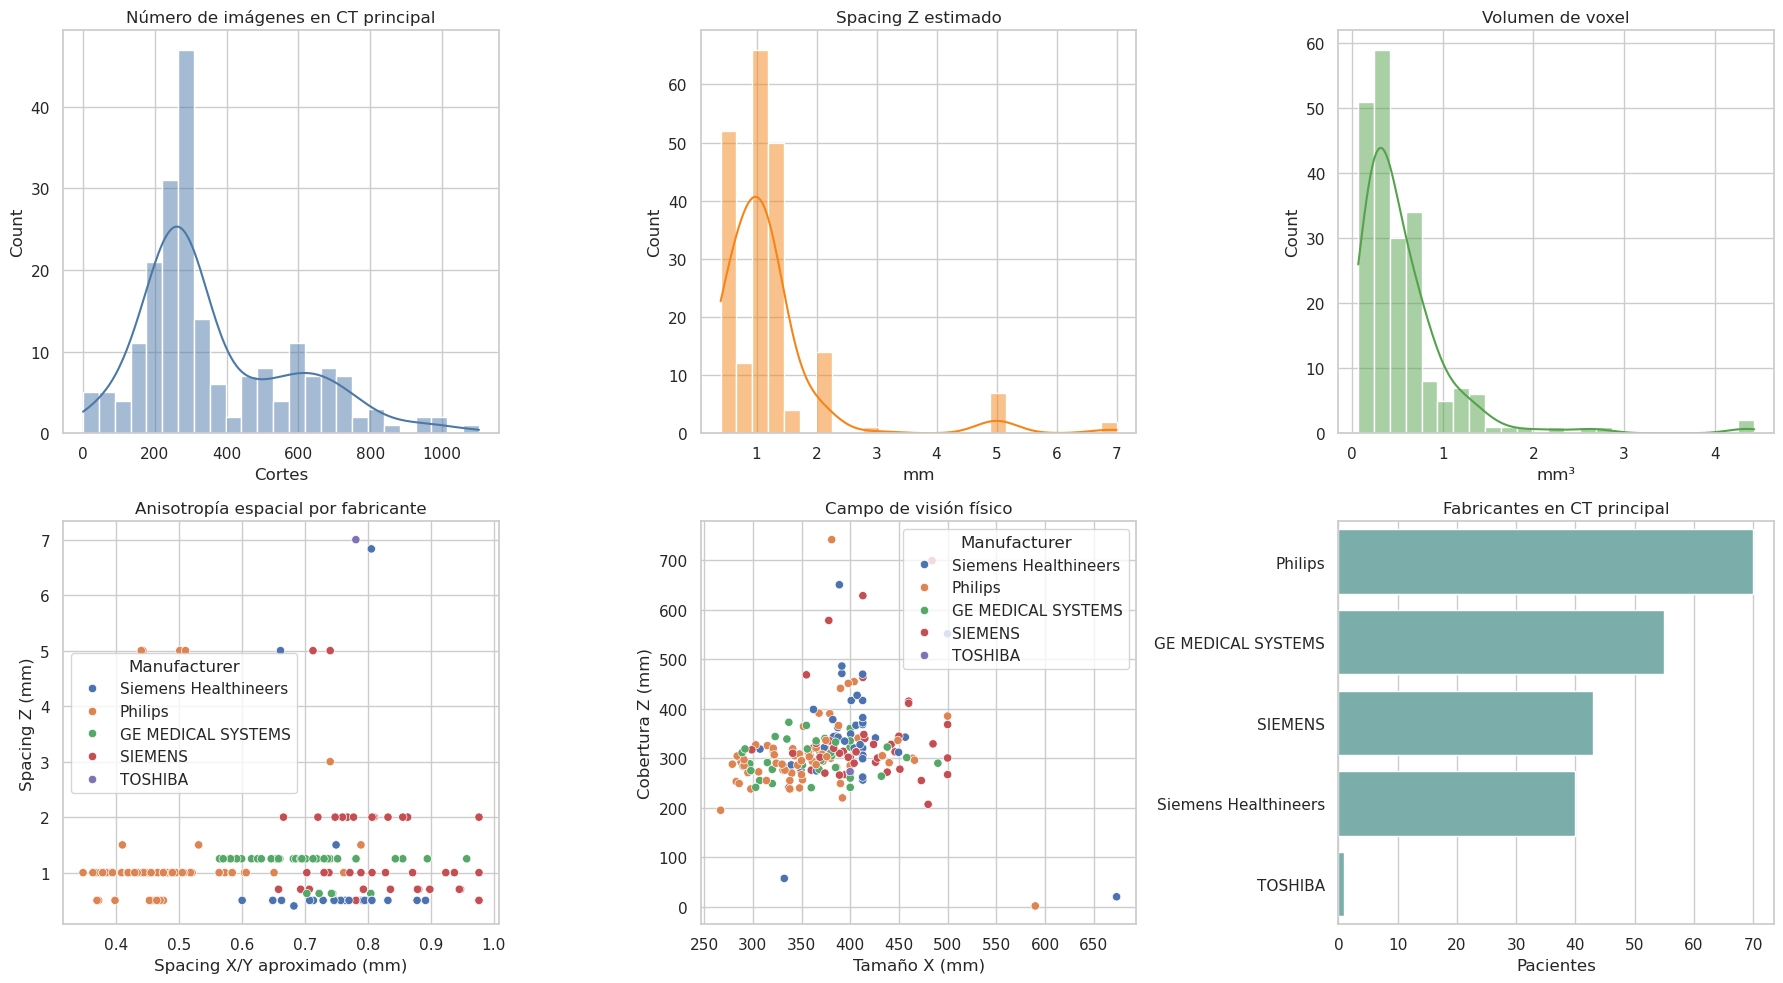

In [31]:
if not df_ct_principal.empty:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    sns.histplot(df_ct_principal["Num_images"], bins=25, kde=True, ax=axes[0, 0], color="#4c78a8")
    axes[0, 0].set_title("Número de imágenes en CT principal")
    axes[0, 0].set_xlabel("Cortes")

    sns.histplot(df_ct_principal["Spacing_Z_best"].dropna(), bins=25, kde=True, ax=axes[0, 1], color="#f58518")
    axes[0, 1].set_title("Spacing Z estimado")
    axes[0, 1].set_xlabel("mm")

    sns.histplot(df_ct_principal["Voxel_volume_mm3"].dropna(), bins=25, kde=True, ax=axes[0, 2], color="#54a24b")
    axes[0, 2].set_title("Volumen de voxel")
    axes[0, 2].set_xlabel("mm³")

    sns.scatterplot(data=df_ct_principal, x="Spacing_X", y="Spacing_Z_best", hue="Manufacturer", ax=axes[1, 0])
    axes[1, 0].set_title("Anisotropía espacial por fabricante")
    axes[1, 0].set_xlabel("Spacing X/Y aproximado (mm)")
    axes[1, 0].set_ylabel("Spacing Z (mm)")

    sns.scatterplot(data=df_ct_principal, x="Size_X_mm", y="Size_Z_mm", hue="Manufacturer", ax=axes[1, 1])
    axes[1, 1].set_title("Campo de visión físico")
    axes[1, 1].set_xlabel("Tamaño X (mm)")
    axes[1, 1].set_ylabel("Cobertura Z (mm)")

    top_manufacturers = df_ct_principal["Manufacturer"].fillna("Desconocido").value_counts().head(10)
    sns.barplot(x=top_manufacturers.values, y=top_manufacturers.index, ax=axes[1, 2], color="#72b7b2")
    axes[1, 2].set_title("Fabricantes en CT principal")
    axes[1, 2].set_xlabel("Pacientes")
    axes[1, 2].set_ylabel("")

    plt.tight_layout()
    plt.show()

### Metadatos de adquisición

Estos metadatos ayudan a detectar efectos de lote: diferentes fabricantes, kernels, kVp o protocolos podrían influir en texturas radiomicas.

In [32]:
if not df_ct_principal.empty:
    acquisition_cols = [
        "Manufacturer", "ManufacturerModelName", "ConvolutionKernel", "KVP", "Exposure",
        "ReconstructionDiameter", "SliceThickness", "Spacing_Z_real", "Spacing_Z_best",
        "RescaleSlope", "RescaleIntercept", "BitsStored", "PixelRepresentation"
    ]
    display(df_ct_principal[acquisition_cols].describe(include="all").T)

    for col in ["Manufacturer", "ManufacturerModelName", "ConvolutionKernel"]:
        counts = df_ct_principal[col].fillna("Desconocido").astype(str).value_counts().head(15)
        print(f"\n{col}")
        display(counts.to_frame("Count"))

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Manufacturer,209,5,Philips,70,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ManufacturerModelName,209,15,Ingenuity Flex,47,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ConvolutionKernel,209,17,LUNG,55,NaN,NaN,NaN,NaN,NaN,NaN,NaN
KVP,209.0,NaN,NaN,NaN,114.210526,12.803008,80.0,100.0,120.0,120.0,140.0
Exposure,209.0,NaN,NaN,NaN,132.507177,103.280198,2.0,15.0,132.0,209.0,450.0
ReconstructionDiameter,209.0,NaN,NaN,NaN,380.58152,50.425589,267.0,349.488055,383.0,408.0,512.0
SliceThickness,208.0,NaN,NaN,NaN,1.589183,1.094062,0.5,1.0,1.25,2.0,10.0
Spacing_Z_real,207.0,NaN,NaN,NaN,1.199316,1.008638,0.4,0.6625,1.0,1.25,7.0
Spacing_Z_best,208.0,NaN,NaN,NaN,1.198358,1.006294,0.4,0.68125,1.0,1.25,7.0
RescaleSlope,209.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0



Manufacturer


,Count
Manufacturer,
Philips,70
GE MEDICAL SYSTEMS,55
SIEMENS,43
Siemens Healthineers,40
TOSHIBA,1



ManufacturerModelName


,Count
ManufacturerModelName,
Ingenuity Flex,47
Optima CT520 Series,43
SOMATOM go.Top,39
Sensation 64,23
Brilliance 64,21
SOMATOM Drive,16
Revolution EVO,6
BrightSpeed,5
Biograph128_Vision 450 Edge,2



ConvolutionKernel


,Count
ConvolutionKernel,
LUNG,55
YA,43
Br60f | 3,32
YB,25
B70f,23
Bl57f | 3,18
Br64f | 3,2
Br40f | 3,2
B,1


### EDA de intensidades HU

Se cargan cortes muestreados de cada CT principal, se aplican `RescaleSlope` y `RescaleIntercept`, y se calculan percentiles de unidades Hounsfield. Si tarda demasiado, reduce `MAX_SLICES_PER_SERIES` o limita `MAX_SERIES_HU`.

In [33]:
RUN_HU_EDA = True
MAX_SERIES_HU = None # si es None = todos los pacientes con CT principal
MAX_SLICES_PER_SERIES = 24 # muestreo uniforme de cortes por paciente
MAX_PIXELS_PER_SLICE = 20000 # submuestreo de pixeles por corte para percentiles


def ordered_files_for_series(series_row):
    rows = df_archivos_dicom[
        (df_archivos_dicom["Paciente"] == series_row["Paciente"])
        & (df_archivos_dicom["SeriesKey"] == series_row["SeriesKey"])
        & (df_archivos_dicom["HasImageGeometry"])
    ].copy()
    if rows.empty:
        return []

    rows["_slice_coord"] = rows.apply(
        lambda r: projected_slice_coordinate(r["ImagePositionPatient"], r["ImageOrientationPatient"]),
        axis=1,
    )
    if rows["_slice_coord"].notna().any():
        rows = rows.sort_values(["_slice_coord", "InstanceNumber", "File"])
    elif rows["InstanceNumber"].notna().any():
        rows = rows.sort_values(["InstanceNumber", "File"])
    else:
        rows = rows.sort_values("File")
    return rows["File"].tolist()


def sample_indices(n, max_items):
    if n <= max_items:
        return np.arange(n)
    return np.unique(np.linspace(0, n - 1, max_items).round().astype(int))


def hu_array_from_dataset(ds):
    arr = ds.pixel_array.astype(np.float32)
    slope = float(getattr(ds, "RescaleSlope", 1) or 1)
    intercept = float(getattr(ds, "RescaleIntercept", 0) or 0)
    return arr * slope + intercept


def compute_hu_stats_for_series(series_row):
    paths = ordered_files_for_series(series_row)
    if not paths:
        raise ValueError("No hay archivos de imagen ordenables para esta serie")

    sampled_values = []
    for idx in sample_indices(len(paths), MAX_SLICES_PER_SERIES):
        ds = dcmread(paths[idx], force=True)
        hu = hu_array_from_dataset(ds).ravel()
        if hu.size > MAX_PIXELS_PER_SLICE:
            hu = hu[:: max(1, hu.size // MAX_PIXELS_PER_SLICE)]
        sampled_values.append(hu)

    values = np.concatenate(sampled_values)
    percentiles = np.percentile(values, [0, 1, 5, 25, 50, 75, 95, 99, 100])
    return {
        "Paciente": series_row["Paciente"],
        "SeriesKey": series_row["SeriesKey"],
        "Num_slices_total": len(paths),
        "Num_slices_sampled": len(sampled_values),
        "HU_min": percentiles[0],
        "HU_p01": percentiles[1],
        "HU_p05": percentiles[2],
        "HU_p25": percentiles[3],
        "HU_p50": percentiles[4],
        "HU_p75": percentiles[5],
        "HU_p95": percentiles[6],
        "HU_p99": percentiles[7],
        "HU_max": percentiles[8],
        "HU_mean": float(np.mean(values)),
        "HU_std": float(np.std(values)),
    }


hu_rows = []
hu_errors = []

if RUN_HU_EDA and not df_ct_principal.empty:
    hu_input = df_ct_principal.copy()
    if MAX_SERIES_HU is not None:
        hu_input = hu_input.head(MAX_SERIES_HU)

    for _, series_row in hu_input.iterrows():
        try:
            hu_rows.append(compute_hu_stats_for_series(series_row))
        except Exception as e:
            hu_errors.append({
                "Paciente": series_row["Paciente"],
                "SeriesKey": series_row["SeriesKey"],
                "Error": str(e),
            })

df_hu_stats = pd.DataFrame(hu_rows)
df_hu_errors = pd.DataFrame(hu_errors)

print("Series con HU calculado:", len(df_hu_stats))
print("Series con error en HU:", len(df_hu_errors))
if not df_hu_stats.empty:
    display(df_hu_stats.describe().T)
    display(df_hu_stats.sort_values("HU_p50").head(10))
if not df_hu_errors.empty:
    display(df_hu_errors.head(20))

Series con HU calculado: 209
Series con error en HU: 0


,count,mean,std,min,25%,50%,75%,max
Num_slices_total,209.0,366.468900,213.756444,1.000000,227.000000,292.000000,497.000000,1102.000000
Num_slices_sampled,209.0,23.684211,2.624916,1.000000,24.000000,24.000000,24.000000,24.000000
HU_min,209.0,-2927.081340,2702.668154,-8192.000000,-3024.000000,-1024.000000,-1024.000000,-1024.000000
HU_p01,209.0,-2888.697608,2684.440263,-8192.000000,-3024.000000,-1024.000000,-1024.000000,-169.800000
HU_p05,209.0,-2750.789474,2591.667674,-8192.000000,-3024.000000,-1024.000000,-1024.000000,-69.000000
HU_p25,209.0,-1027.947368,509.702583,-8192.000000,-1024.000000,-1003.000000,-977.000000,-50.000000
HU_p50,209.0,-781.052632,582.511509,-8192.000000,-915.000000,-877.000000,-685.000000,26.000000
HU_p75,209.0,-107.080144,577.693548,-8190.000000,-80.000000,-42.000000,-13.000000,69.000000
HU_p95,209.0,174.594498,54.239639,56.000000,139.000000,173.000000,205.000000,429.000000
HU_p99,209.0,499.341388,126.895474,103.000000,419.000000,490.000000,576.000000,935.000000


,Paciente,SeriesKey,Num_slices_total,Num_slices_sampled,HU_min,HU_p01,HU_p05,HU_p25,HU_p50,HU_p75,HU_p95,HU_p99,HU_max,HU_mean,HU_std
115,205HENX,1.2.840.113704.7.32.0.113704.7.1.0.86591951131...,3,3,-8192.0,-8192.0,-8192.0,-8192.0,-8192.0,-8190.0,56.0,103.0,1476.0,-6413.031738,3279.914062
117,207HLSN,1.2.840.113704.7.32.1.2.840.113704.1.111.7976....,2,2,-1024.0,-1024.0,-1024.0,-1024.0,-1024.0,-939.0,110.0,454.0,3068.0,-850.719971,392.956543
120,20MMNX,1.2.840.113704.7.32.013619.2.55.3.1762277902.6...,232,24,-3024.0,-3024.0,-3024.0,-1024.0,-992.0,-873.0,80.0,272.0,2166.0,-1215.129028,1025.138550
162,58MASH,1.2.840.113704.7.32.07.5.1.4.55447.30000020010...,267,24,-1024.0,-1024.0,-1024.0,-1024.0,-991.0,-860.0,86.0,297.0,2173.0,-787.957153,399.259308
67,161HASN,1.2.840.113704.7.32.0.5.1.7.119428.30000023103...,1102,24,-8192.0,-8192.0,-8192.0,-1032.0,-990.0,-584.0,89.0,384.0,6363.0,-2270.078857,3117.441162
121,210MASN,1.2.840.113704.7.32.0.5.1.7.119428.30000024041...,854,24,-8192.0,-8192.0,-8192.0,-1034.0,-977.0,-716.0,137.0,458.0,3329.0,-2123.833496,3009.461182
159,55HASN,1.2.840.113704.7.32.0036.9116.2.2.2.1762668448...,39,24,-2048.0,-2048.0,-2048.0,-2048.0,-976.0,-65.0,100.0,360.0,1625.0,-942.326965,786.471985
61,156MNnNX,1.2.840.113704.7.32.0619.2.491.3.1762277902.49...,241,24,-3024.0,-3024.0,-3024.0,-1024.0,-976.0,-145.0,174.0,432.0,3071.0,-1117.937256,1084.169556
167,62HENX,1.2.840.113704.7.32.07.5.1.4.31434.30000019120...,184,24,-1024.0,-1024.0,-1024.0,-1024.0,-975.0,-81.0,110.0,305.0,1846.0,-667.293457,474.449890
179,73MASN,1.2.840.113704.7.32.0619.2.278.3.1745541162.66...,275,24,-3024.0,-3024.0,-3024.0,-1024.0,-968.0,-74.0,188.0,491.0,2889.0,-1083.821533,1108.862549


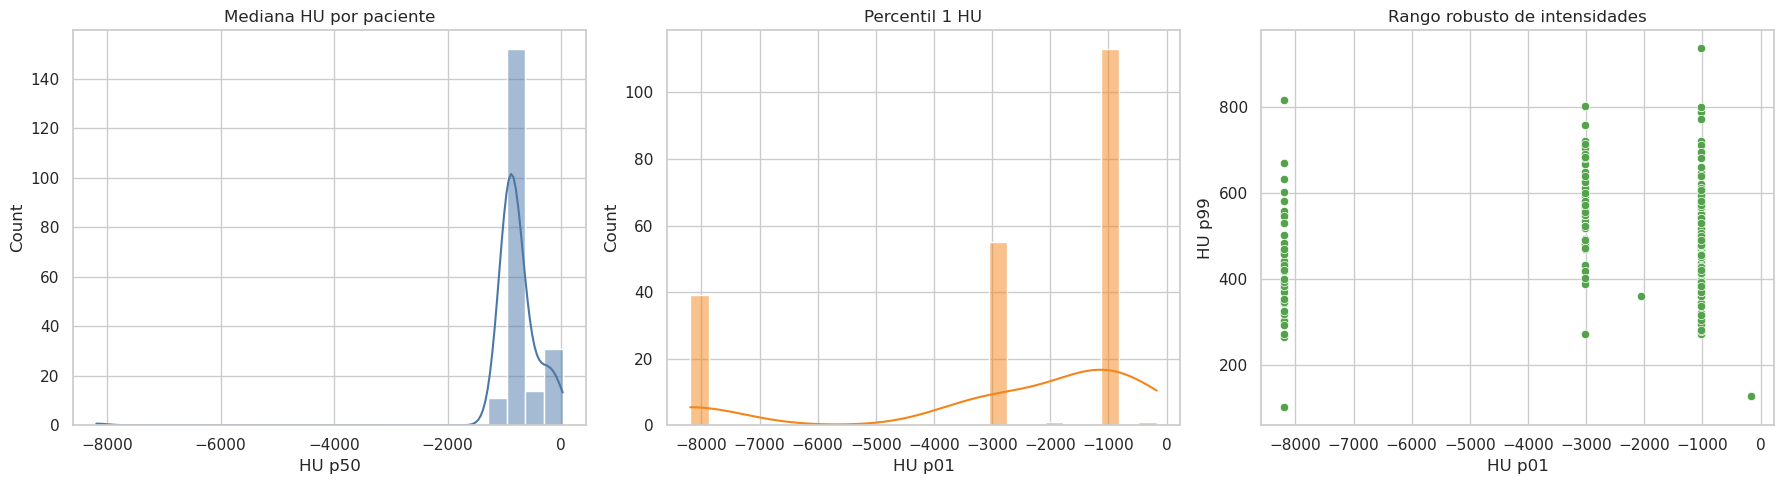

In [34]:
if 'df_hu_stats' in globals() and not df_hu_stats.empty:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    sns.histplot(df_hu_stats["HU_p50"], bins=25, kde=True, ax=axes[0], color="#4c78a8")
    axes[0].set_title("Mediana HU por paciente")
    axes[0].set_xlabel("HU p50")

    sns.histplot(df_hu_stats["HU_p01"], bins=25, kde=True, ax=axes[1], color="#f58518")
    axes[1].set_title("Percentil 1 HU")
    axes[1].set_xlabel("HU p01")

    sns.scatterplot(data=df_hu_stats, x="HU_p01", y="HU_p99", ax=axes[2], color="#54a24b")
    axes[2].set_title("Rango robusto de intensidades")
    axes[2].set_xlabel("HU p01")
    axes[2].set_ylabel("HU p99")

    plt.tight_layout()
    plt.show()

### Control visual de calidad

Se muestran cortes centrales de pacientes representativos: pocos cortes, muchos cortes, spacing Z alto y una muestra aleatoria. Sirve para detectar orientaciones incorrectas, series no axiales o CT que no corresponden al volumen esperado.

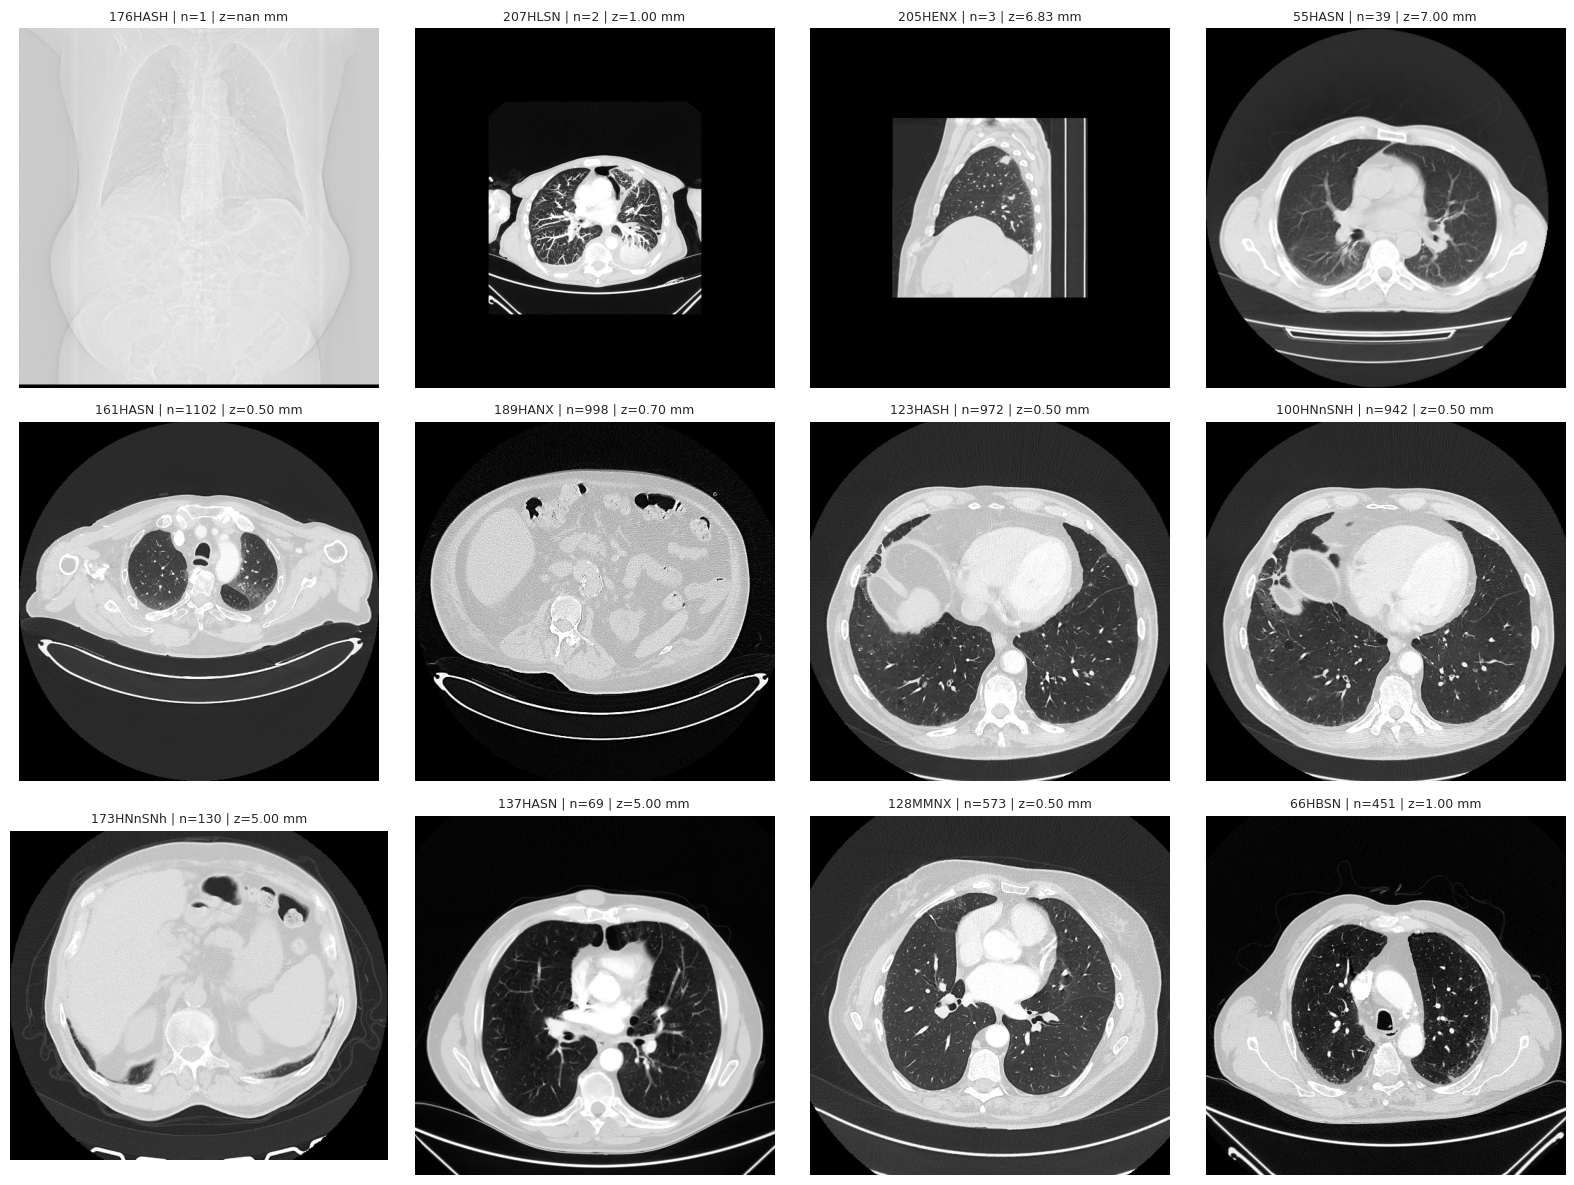

In [35]:
RUN_VISUAL_QA = True
MAX_QA_CASES = 12
WINDOW_CENTER = -500
WINDOW_WIDTH = 1500


def load_middle_hu_slice(series_row):
    paths = ordered_files_for_series(series_row)
    if not paths:
        raise ValueError("Serie sin archivos de imagen")
    middle_path = paths[len(paths) // 2]
    ds = dcmread(middle_path, force=True)
    return hu_array_from_dataset(ds), middle_path


def window_image(image, center=WINDOW_CENTER, width=WINDOW_WIDTH):
    low = center - width / 2
    high = center + width / 2
    return np.clip(image, low, high)

if RUN_VISUAL_QA and not df_ct_principal.empty:
    qa_cases = pd.concat([
        df_ct_principal.sort_values("Num_images").head(4),
        df_ct_principal.sort_values("Num_images", ascending=False).head(4),
        df_ct_principal.sort_values("Spacing_Z_best", ascending=False).head(4),
        df_ct_principal.sample(min(4, len(df_ct_principal)), random_state=42),
    ], ignore_index=True).drop_duplicates("Paciente").head(MAX_QA_CASES)

    n_cases = len(qa_cases)
    n_cols = 4
    n_rows = int(np.ceil(n_cases / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
    axes = np.asarray(axes).reshape(-1)

    for ax, (_, row) in zip(axes, qa_cases.iterrows()):
        try:
            image, middle_path = load_middle_hu_slice(row)
            ax.imshow(window_image(image), cmap="gray")
            ax.set_title(
                f"{row['Paciente']} | n={int(row['Num_images'])} | z={row['Spacing_Z_best']:.2f} mm",
                fontsize=9,
            )
        except Exception as e:
            ax.text(0.5, 0.5, f"{row['Paciente']}\n{e}", ha="center", va="center", fontsize=8)
        ax.axis("off")

    for ax in axes[n_cases:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

### Cruce con datos clínicos y NIfTI convertidos

Este bloque comprueba cobertura entre pacientes con DICOM original, CT principal seleccionada, NIfTI convertido y tabla clínica. También permite revisar si variables clínicas o la complicación están asociadas a diferencias de adquisición.

In [36]:
CLINICAL_PATH = Path("/home/mcribilles/tfm/clinical_data/210pacientes/clinical_data.csv")
NIFTI_DIR = Path("/home/mcribilles/tfm/nifti_convertidos_anonimizados")

all_patient_ids = sorted([p.name for p in pacientes])
df_cobertura = pd.DataFrame({"Paciente": all_patient_ids})
df_cobertura["Tiene_carpeta_DICOM"] = True
df_cobertura["Tiene_CT_principal"] = df_cobertura["Paciente"].isin(df_ct_principal["Paciente"])
df_cobertura["Tiene_NIfTI"] = df_cobertura["Paciente"].apply(lambda x: (NIFTI_DIR / f"{x}.nii.gz").exists())

if CLINICAL_PATH.exists():
    df_clinical = pd.read_csv(CLINICAL_PATH)
    patient_col = "patient_id" if "patient_id" in df_clinical.columns else df_clinical.columns[0]
    clinical_ids = set(df_clinical[patient_col].astype(str))
    df_cobertura["Tiene_clinica"] = df_cobertura["Paciente"].isin(clinical_ids)
else:
    df_clinical = pd.DataFrame()
    patient_col = None
    df_cobertura["Tiene_clinica"] = False

print("Cobertura general")
display(df_cobertura[["Tiene_CT_principal", "Tiene_NIfTI", "Tiene_clinica"]].sum().to_frame("Pacientes"))

display(df_cobertura[~df_cobertura[["Tiene_CT_principal", "Tiene_NIfTI", "Tiene_clinica"]].all(axis=1)].head(50))

if not df_clinical.empty:
    df_ct_clinical = df_ct_principal.merge(
        df_clinical,
        left_on="Paciente",
        right_on=patient_col,
        how="inner",
    )
    print("Pacientes con CT principal y clínica:", len(df_ct_clinical))
    display(df_ct_clinical.head())
else:
    df_ct_clinical = pd.DataFrame()

Cobertura general


,Pacientes
Tiene_CT_principal,209
Tiene_NIfTI,206
Tiene_clinica,210


,Paciente,Tiene_carpeta_DICOM,Tiene_CT_principal,Tiene_NIfTI,Tiene_clinica
72,166MANX,True,False,False,True
83,176HASH,True,True,False,True
116,205HENX,True,True,False,True
118,207HLSN,True,True,False,True


Pacientes con CT principal y clínica: 209


,Paciente,SeriesKey,SeriesInstanceUID,StudyInstanceUID,Modality,SeriesDescription,ProtocolName,Num_files,Num_images,Height,Width,Spacing_X,Spacing_Y,SliceThickness,SpacingBetweenSlices,Manufacturer,ManufacturerModelName,ConvolutionKernel,KVP,Exposure,ReconstructionDiameter,RescaleSlope,RescaleIntercept,BitsStored,PixelRepresentation,Num_unique_rows,Num_unique_columns,Num_unique_spacing_x,Num_unique_spacing_y,Duplicate_instance_count,Example_file,Num_unique_positions,Duplicate_position_count,Spacing_Z_real,Spacing_Z_std,Coverage_Z_mm,Inconsistent_dimensions,Inconsistent_xy_spacing,Spacing_Z_best,Is_CT_candidate,Selected_CT,Size_X_mm,Size_Y_mm,Size_Z_mm,Voxel_volume_mm3,Approx_volume_cm3,patient_id,Sexo,Edad,Tipo de cáncer,Complicación,Tipo de complicación,Factor de riesgo,Patología pulmonar
0,100HNnSNH,1.2.840.113704.7.32.0.5.1.7.119428.30000022042...,1.2.840.113704.7.32.0.5.1.7.119428.30000022042...,1.2.840.113564.99.1.71094327433004.16.20224271...,CT,"Tórax 1,00 Br60 S3",TORAX CONTRASTE,942,942,512.0,512.0,0.764504,0.764504,1.00,NaN,Siemens Healthineers,SOMATOM go.Top,Br60f | 3,90.0,300.0,391.426621,1.0,-8192.0,16.0,0.0,1,1,1,1,0,/home/mcribilles/tfm/casosradiomica/100HNnSNH/...,942,0.0,0.50,0.0,471.00,False,False,0.50,True,True,391.425995,391.425995,471.00,0.292233,72163.939757,100HNnSNH,Hombre,76,X,Sí,"Neumotórax, Hemorragia","HTA, Tabaquismo",Enfisema centrolobulillar
1,101HNnSN,1.2.840.113704.7.32.1.2.840.113704.1.111.8748....,1.2.840.113704.7.32.1.2.840.113704.1.111.8748....,1.2.840.113704.1.111.8748.1621965734.1,CT,Pulmon,TORAX/Thorax,217,217,768.0,768.0,0.410156,0.410156,3.00,1.50,Philips,Ingenuity Flex,YA,120.0,159.0,315.000000,1.0,-1024.0,12.0,0.0,1,1,1,1,0,/home/mcribilles/tfm/casosradiomica/101HNnSN/0...,217,0.0,1.50,0.0,325.50,False,False,1.50,True,True,315.000000,315.000000,325.50,0.252342,32297.737500,101HNnSN,Hombre,53,X,Sí,Neumotórax,"Tabaquismo, DM",X
2,102HANX,1.2.840.113704.7.32.0.5.1.7.119428.30000021061...,1.2.840.113704.7.32.0.5.1.7.119428.30000021061...,1.2.840.113564.99.1.71094327433004.97.20216111...,CT,"Tórax 1,00 Br60 S3",BIOPSIA TORAX,115,115,512.0,512.0,0.649063,0.649063,1.00,NaN,Siemens Healthineers,SOMATOM go.Top,Br60f | 3,90.0,300.0,332.320297,1.0,-8192.0,16.0,0.0,1,1,1,1,0,/home/mcribilles/tfm/casosradiomica/102HANX/RO...,115,0.0,0.50,0.0,57.50,False,False,0.50,True,True,332.320007,332.320007,57.50,0.210641,6350.103768,102HANX,Hombre,77,Adenocarcinoma,No,X,HTA,X
3,103MANX,1.2.840.113704.7.32.1.2.840.113704.1.111.9212....,1.2.840.113704.7.32.1.2.840.113704.1.111.9212....,1.2.840.113704.1.111.9212.1624016572.1,CT,Pulmon 2mm,TORAX SIN CIV/BODY,253,253,768.0,768.0,0.368490,0.368490,2.00,1.00,Philips,Ingenuity Flex,YA,120.0,127.0,283.000000,1.0,-1024.0,12.0,0.0,1,1,1,1,0,/home/mcribilles/tfm/casosradiomica/103MANX/IG...,253,0.0,1.00,0.0,253.00,False,False,1.00,True,True,283.000008,283.000008,253.00,0.135785,20262.518092,103MANX,Mujer,75,Adenocarcinoma,No,X,Tabaquismo,X
4,104HASN,1.2.840.113704.7.32.0619.2.278.3.1745541162.27...,1.2.840.113704.7.32.0619.2.278.3.1745541162.27...,1.2.840.113619.2.278.3.1745541162.273.16203663...,CT,1.25 PULMON,5.2 TORAX CONTRASTE (SMART PREP),211,211,512.0,512.0,0.843750,0.843750,1.25,-1.25,GE MEDICAL SYSTEMS,Optima CT520 Series,LUNG,100.0,10.0,432.000000,1.0,-1024.0,16.0,1.0,1,1,1,1,0,/home/mcribilles/tfm/casosradiomica/104HASN/PP...,211,0.0,1.25,0.0,263.75,False,False,1.25,True,True,432.000000,432.000000,263.75,0.889893,49222.080000,104HASN,Hombre,76,Adenocarcinoma,Sí,Neumotórax,"Extabaquismo, HTA","Fibrosis, Bronquiectasias"


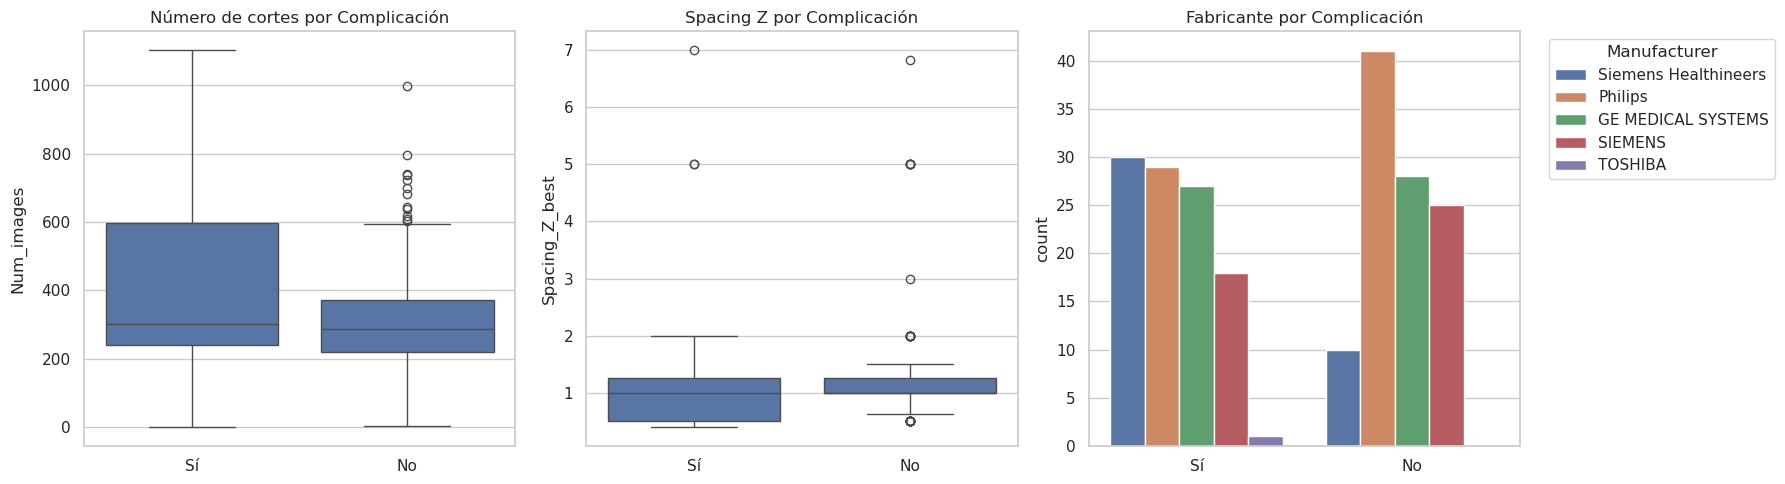

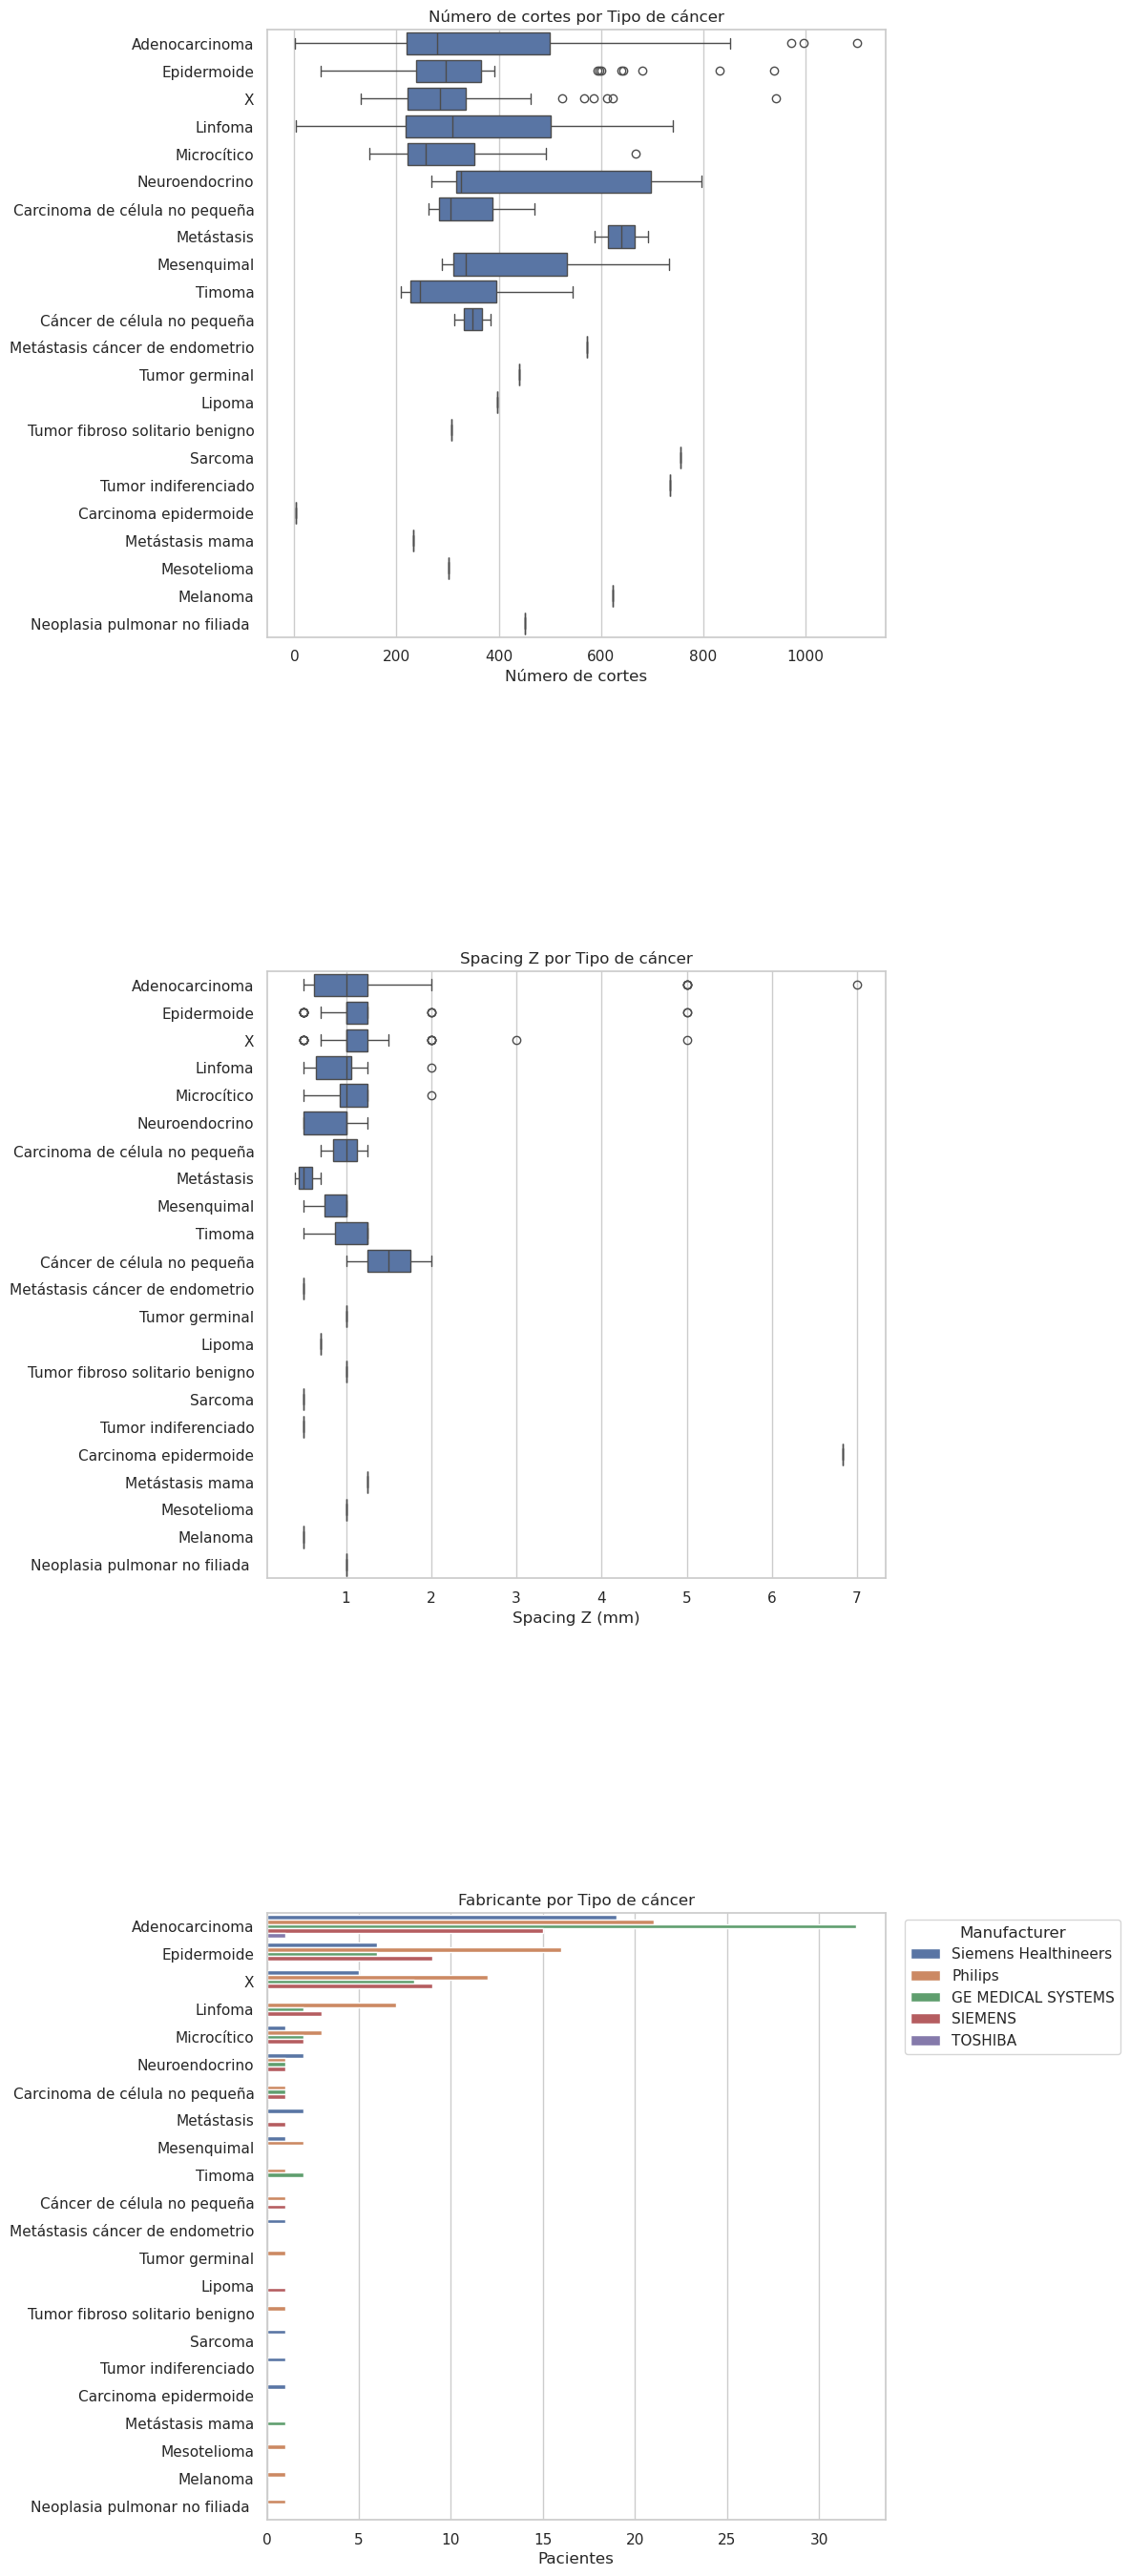

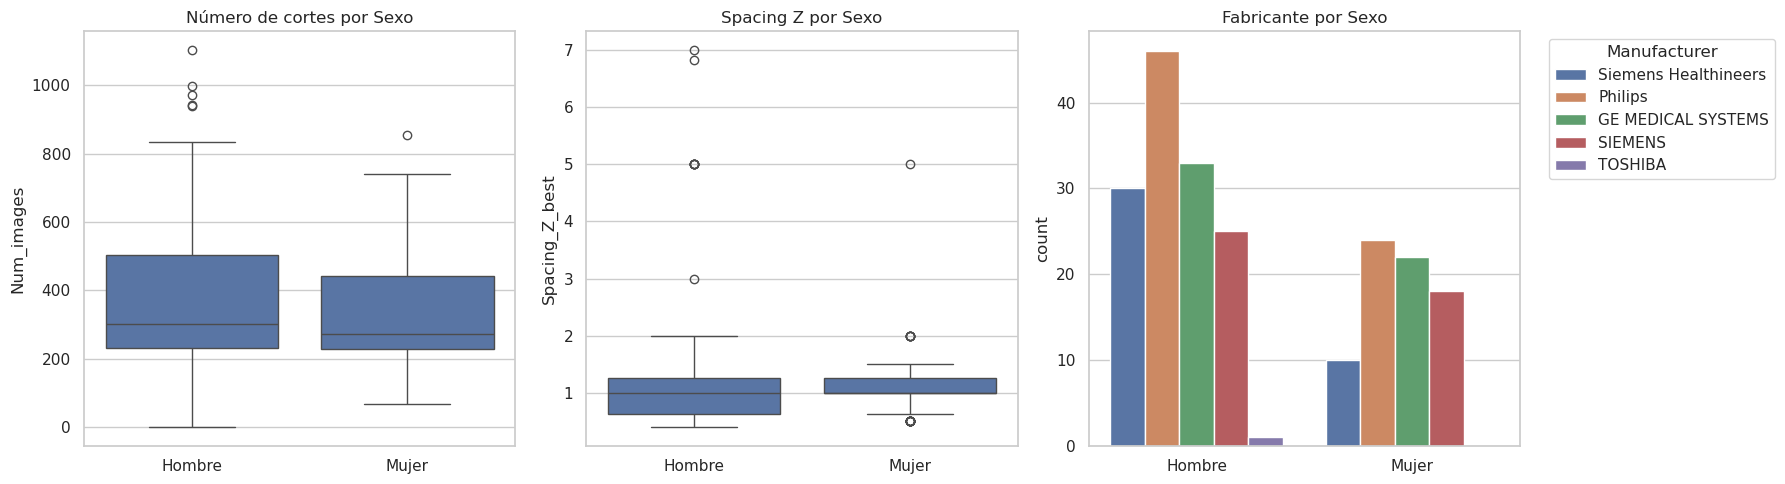

In [39]:
if 'df_ct_clinical' in globals() and not df_ct_clinical.empty:
    candidate_targets = ["Complicación", "Complicacion_binaria", "Tipo de cáncer", "Sexo"]
    available_targets = [col for col in candidate_targets if col in df_ct_clinical.columns]

    for target in available_targets:
        order = df_ct_clinical[target].fillna("Desconocido").astype(str).value_counts().index.tolist()
        n_categories = len(order)
        max_label_len = max([len(label) for label in order], default=0)
        use_horizontal_layout = target == "Tipo de cáncer" or n_categories > 4 or max_label_len > 14

        if use_horizontal_layout:
            panel_height = max(3.2, 0.45 * n_categories + 1.4)
            fig, axes = plt.subplots(3, 1, figsize=(12, panel_height * 3))

            sns.boxplot(data=df_ct_clinical, y=target, x="Num_images", order=order, ax=axes[0])
            axes[0].set_title(f"Número de cortes por {target}")
            axes[0].set_xlabel("Número de cortes")
            axes[0].set_ylabel("")

            sns.boxplot(data=df_ct_clinical, y=target, x="Spacing_Z_best", order=order, ax=axes[1])
            axes[1].set_title(f"Spacing Z por {target}")
            axes[1].set_xlabel("Spacing Z (mm)")
            axes[1].set_ylabel("")

            sns.countplot(data=df_ct_clinical, y=target, hue="Manufacturer", order=order, ax=axes[2])
            axes[2].set_title(f"Fabricante por {target}")
            axes[2].set_xlabel("Pacientes")
            axes[2].set_ylabel("")
            axes[2].legend(title="Manufacturer", bbox_to_anchor=(1.02, 1), loc="upper left")

            plt.subplots_adjust(left=0.28, right=0.82, hspace=0.55)
        else:
            fig, axes = plt.subplots(1, 3, figsize=(18, 5))

            sns.boxplot(data=df_ct_clinical, x=target, y="Num_images", order=order, ax=axes[0])
            axes[0].set_title(f"Número de cortes por {target}")
            axes[0].set_xlabel("")
            axes[0].tick_params(axis="x", rotation=0)

            sns.boxplot(data=df_ct_clinical, x=target, y="Spacing_Z_best", order=order, ax=axes[1])
            axes[1].set_title(f"Spacing Z por {target}")
            axes[1].set_xlabel("")
            axes[1].tick_params(axis="x", rotation=0)

            sns.countplot(data=df_ct_clinical, x=target, hue="Manufacturer", order=order, ax=axes[2])
            axes[2].set_title(f"Fabricante por {target}")
            axes[2].set_xlabel("")
            axes[2].tick_params(axis="x", rotation=0)
            axes[2].legend(title="Manufacturer", bbox_to_anchor=(1.05, 1), loc="upper left")

            plt.tight_layout()

        plt.show()


### Exportación de resultados del EDA DICOM

Se guardan tablas intermedias.

In [40]:
exports = {
    "dicom_archivos_metadata.csv": df_archivos_dicom,
    "dicom_errores_lectura.csv": df_errores_lectura_dicom,
    "dicom_series_resumen.csv": df_series_dicom,
    "dicom_ct_principal.csv": df_ct_principal,
    "dicom_alertas_series.csv": df_alertas_series,
    "dicom_pacientes_sin_ct.csv": df_pacientes_sin_ct,
    "dicom_cobertura_clinica_nifti.csv": df_cobertura,
}

if 'df_hu_stats' in globals():
    exports["dicom_hu_stats.csv"] = df_hu_stats
if 'df_hu_errors' in globals():
    exports["dicom_hu_errors.csv"] = df_hu_errors

for filename, df_export in exports.items():
    output_path = EDA_OUTPUT_DIR / filename
    df_export.to_csv(output_path, index=False)
    print(output_path)

/home/mcribilles/tfm/eda/dicom_archivos_metadata.csv
/home/mcribilles/tfm/eda/dicom_errores_lectura.csv
/home/mcribilles/tfm/eda/dicom_series_resumen.csv
/home/mcribilles/tfm/eda/dicom_ct_principal.csv
/home/mcribilles/tfm/eda/dicom_alertas_series.csv
/home/mcribilles/tfm/eda/dicom_pacientes_sin_ct.csv
/home/mcribilles/tfm/eda/dicom_cobertura_clinica_nifti.csv
/home/mcribilles/tfm/eda/dicom_hu_stats.csv
/home/mcribilles/tfm/eda/dicom_hu_errors.csv


## Conclusiones del EDA de volúmenes DICOM

### Cobertura y selección de series

El conjunto original contiene 210 carpetas de pacientes. Tras analizar las series DICOM de forma individual se detectaron 1267 series en 209 pacientes, con una mediana de 6 series por paciente. Esto confirma que no es correcto interpretar cada carpeta como un único volumen: dentro de cada paciente hay varias series y no todas corresponden a la CT axial útil.

La selección automática de la serie CT principal identificó 209 CT principales. El único paciente sin CT principal seleccionada fue `166MANX`, que además aparece sin NIfTI convertido. La cobertura clínica es completa para los 210 pacientes, mientras que la cobertura NIfTI es de 206 pacientes. Los pacientes sin NIfTI son `166MANX`, `176HASH`, `205HENX` y `207HLSN`, lo que coincide con los casos más problemáticos del EDA de los volúmenes DICOM.

### Calidad de las CT seleccionadas

La mayoría de las CT principales son técnicamente coherentes, pero hay tres pacientes que requieren revisión o exclusión antes de cualquier análisis 3D:

- `176HASH`: solo 1 imagen en la CT seleccionada y spacing Z no estimable.
- `205HENX`: solo 3 imágenes, spacing XY inconsistente y spacing Z variable.
- `207HLSN`: solo 2 imágenes, `InstanceNumber` duplicado y posición de corte duplicada.

Estos casos explican por qué no aparecen como NIfTI convertidos y no deberían usarse para extracción radiomica volumétrica sin revisión manual. Otros pacientes con pocos cortes o spacing Z alto, como `55HASN`, `50HANX`, `36HENX`, `24MANX`, `19MANX` o `137HASN`, también son candidatos a inspección visual porque pueden tener menor cobertura anatómica o adquisición más gruesa.

### Heterogeneidad espacial

El número de cortes por CT principal es muy variable: mediana de 292 cortes, rango de 1 a 1102, con percentil 25 en 227 y percentil 75 en 497. Esta dispersión indica una heterogeneidad importante de cobertura o protocolo de adquisición.

La resolución en plano está dominada por matrices de 512x512 y 768x768: 140 CT son 512x512, 66 son 768x768 y solo aparecen casos aislados con otras resoluciones. El spacing X/Y tiene mediana aproximada de 0.72 mm, pero varía entre 0.35 y 1.00 mm. El spacing Z estimado tiene mediana de 1.00 mm, con IQR 0.68-1.25 mm, aunque hay casos extremos de hasta 7 mm.

El volumen de voxel también es heterogéneo: mediana de 0.38 mm³, IQR 0.25-0.70 mm³ y máximo de 4.43 mm³. Por tanto, para radiomica 3D es recomendable aplicar resampling espacial antes de extraer características, porque las texturas pueden depender fuertemente del tamaño de voxel y del grosor de corte.

### Metadatos de adquisición y posible efecto de lote

Los estudios proceden de varios fabricantes: Philips (70), GE MEDICAL SYSTEMS (55), SIEMENS (43), Siemens Healthineers (40) y un caso TOSHIBA. También hay variabilidad en modelos, kernels de reconstrucción y kVp. Los kernels más frecuentes son `LUNG`, `YA`, `Br60f | 3`, `YB` y `B70f`; el kVp más habitual es 120, pero también aparecen 100, 90, 140, 110, 130 y 80.

Esta variabilidad es relevante porque fabricante, modelo, kernel, kVp y grosor de corte pueden modificar las intensidades y texturas de la imagen. En un pipeline radiomico conviene controlar estos posibles efectos de lote mediante resampling, normalización HU, selección de características robustas y, si procede, armonización o análisis estratificado.

### Intensidades HU

El EDA de intensidades se calculó para las 209 CT principales. La mediana global de `HU_p50` por paciente es aproximadamente -877 HU, compatible con que muchas imágenes están dominadas por parénquima pulmonar/aire. El percentil 95 tiene mediana de 173 HU y el percentil 99 mediana de 490 HU, valores razonables para CT torácica con tejidos blandos y estructuras de alta densidad.

Hay outliers claros en HU. `205HENX` presenta `HU_p50 = -8192`, lo que refuerza que es un caso no válido o mal convertido/leído para análisis volumétrico. `176HASH` tiene una mediana HU positiva con una sola imagen, por lo que tampoco es representativo. Estos resultados apoyan excluir o revisar manualmente los pacientes ya marcados por las alertas geométricas.

### Relación con variables clínicas

Al cruzar las CT principales con los datos clínicos hay 209 pacientes con CT y clínica. Por tipo de cáncer, el grupo mayoritario es Adenocarcinoma (88 pacientes), seguido de Epidermoide (37), `X`/no especificado (34), Linfoma (12) y Microcítico (8). Muchas categorías tienen muy pocos pacientes, incluso n=1.

En los gráficos por tipo de cáncer no se observa una separación fuerte y estable del número de cortes o spacing Z para los grupos principales. Adenocarcinoma, Epidermoide, `X`, Linfoma y Microcítico tienen medianas de spacing Z alrededor de 1 mm y rangos intercuartílicos relativamente parecidos. Las diferencias más llamativas aparecen en categorías minoritarias y suelen corresponder a casos concretos u outliers, por ejemplo `Carcinoma epidermoide` con 3 cortes y spacing Z de 6.83 mm, que corresponde al caso problemático `205HENX`.

Por complicación, los pacientes con complicación y sin complicación tienen medianas similares: 303 frente a 287 cortes y spacing Z mediano de 1 mm en ambos grupos. Aun así, el grupo con complicación tiene un IQR de cortes más amplio y mayor presencia relativa de Siemens Healthineers, por lo que no se puede descartar completamente un efecto de adquisición asociado a la distribución clínica. Esto debe tratarse como posible factor de confusión, no como una conclusión causal.

### Implicaciones para el preprocesamiento

Por tanto, antes de entrenar modelos o extraer características radiomicas tendremos que:

- excluir o revisar manualmente `166MANX`, `176HASH`, `205HENX` y `207HLSN`
- usar la CT principal seleccionada por serie, no la primera imagen de la carpeta
- ordenar cortes por posición espacial, no solo por nombre de archivo
- aplicar resampling espacial común, especialmente por la variabilidad en spacing Z y volumen de voxel
- normalizar o acotar intensidades HU de forma consistente
- documentar fabricante, kernel y kVp como posibles fuentes de sesgo
- agrupar o limpiar categorías clínicas raras antes de comparar por tipo de cáncer, ya que muchas tienen tamaño muestral insuficiente.

En resumen, el dataset DICOM es mayoritariamente aprovechable para análisis volumétrico, pero presenta heterogeneidad espacial y de adquisición suficiente como para justificar un preprocesamiento cuidadoso. Las conclusiones principales son que la selección por serie es imprescindible, que hay pocos casos claramente no válidos, y que cualquier análisis radiomico posterior debe controlar la variabilidad de resolución, spacing, fabricante y protocolo.